# 🛒 Customer Churn Prediction – E-Commerce Platform

## STAT3013 – Information System Analysis & Design Project

**End-to-end pipeline (2024-2025 SOTA):**

`EDA → Outlier Handling → Feature Engineering → Inferential Statistics → CLV Regression → SEM → ML (LightGBM + CatBoost) → DL (FT-Transformer + TabNet) → SHAP → Dashboard Export`


### ✅ Models used (modern 2024-2025):
| # | Model | Type | Year | Paper / Source |
|---|-------|------|------|----------------|
| ML1 | **LightGBM** | Gradient Boosting | Microsoft 2017 | Ke et al., NeurIPS 2017 |
| ML2 | **CatBoost** | Gradient Boosting | Yandex 2018 | Prokhorenkova et al., NeurIPS 2018 |
| DL1 | **FT-Transformer** | Transformer for tabular | Yandex 2022 | Gorishniy et al., NeurIPS 2021 |
| DL2 | **TabNet** | Attention-based DL | Google 2021 | Arik & Pfister, AAAI 2021 |

> 📖 **Why these models?** The survey *"Revisiting Deep Learning Models for Tabular Data"* (Gorishniy et al., NeurIPS 2021) shows FT-Transformer outperforms MLP on tabular classification. CatBoost ranked #1 in multiple Kaggle Fraud/Churn benchmarks 2023-2024.

---

### 📋 Notebook structure:
1. Library installation
2. Imports
3. Data loading
4. Exploratory Data Analysis (EDA)
5. Outlier handling (Winsorization)
6. Feature Engineering
7. Inferential Statistics (T-test, Chi-square)
8. CLV Regression (Gradient Boosting)
9. SEM – Structural Equation Modeling
10. ML/DL preprocessing pipeline
11. LightGBM + SHAP + 5-Fold CV
12. CatBoost
13. FT-Transformer
14. TabNet
15. Model Comparison
16. Export CSV for Looker Studio
17. Conclusions & Business implications

## 📦 0. Install libraries (run once)

> **Colab note:** after installation, restart the runtime if prompted, then re-run from Cell 1.

In [1]:
# Install required libraries (first run or whenever you change runtime)
!pip install --upgrade pip --quiet
!pip install "numpy>=1.22.4,<2.0.0" --quiet
!pip install lightgbm==4.3.0 catboost==1.2.5 shap==0.45.0 --quiet
!pip install imbalanced-learn==0.12.3 --quiet
!pip install pytorch-tabnet==4.1.0 --quiet
!pip install semopy==2.3.11 --quiet
!pip install openpyxl --quiet
print("✅ Installation complete! If Colab asks, restart runtime then re-run from top.")

✅ Installation complete! If Colab asks, restart runtime then re-run from top.


## 📚 1. Import libraries

In [2]:
# ----- Data handling -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

# ----- Preprocessing -----
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE

# ----- ML models -----
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ----- CLV Regression -----
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ----- Classification metrics -----
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc,
    average_precision_score, precision_recall_curve
)

# ----- SHAP (model explainability) -----
import shap

# ----- Deep Learning -----
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier

# ----- SEM (Structural Equation Modeling) -----
try:
    import semopy
    SEM_AVAILABLE = True
    print("✅ semopy loaded (full SEM will run)")
except ImportError:
    SEM_AVAILABLE = False
    print("⚠️  semopy not available – SEM path diagram only")

import warnings
warnings.filterwarnings("ignore")

# ----- Global settings -----
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Imports complete")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Device:  {DEVICE}")
print(f"   • Seed:    {SEED}")

✅ semopy loaded (full SEM will run)
✅ Imports complete
   • PyTorch: 2.10.0+cpu
   • Device:  cpu
   • Seed:    42


In [3]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    DEVICE = 'cuda'
else:
    print("❌ GPU is not available. Running on CPU.")
    DEVICE = 'cpu'

❌ GPU is not available. Running on CPU.


## 📂 2. Load the dataset


In [4]:


# ===== file dragged into Colab =====
FILE_PATH = 'DataPttk_E_commerce.xlsx'

df = pd.read_excel(FILE_PATH)

print(f"📊 Shape:      {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Churn rate: {df['Churn'].mean()*100:.2f}%  "
      f"({df['Churn'].sum()} churn / {(df['Churn']==0).sum()} non-churn)")
print(f"\n📋 Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

df.head()

📊 Shape:      5,630 rows × 20 columns
🎯 Churn rate: 16.84%  (948 churn / 4682 non-churn)

📋 Columns:
    1. CustomerID
    2. Churn
    3. Tenure
    4. PreferredLoginDevice
    5. CityTier
    6. WarehouseToHome
    7. PreferredPaymentMode
    8. Gender
    9. HourSpendOnApp
   10. NumberOfDeviceRegistered
   11. PreferedOrderCat
   12. SatisfactionScore
   13. MaritalStatus
   14. NumberOfAddress
   15. Complain
   16. OrderAmountHikeFromlastYear
   17. CouponUsed
   18. OrderCount
   19. DaySinceLastOrder
   20. CashbackAmount


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 🔍 3. Exploratory Data Analysis (EDA)

### 3.1 Overview

In [5]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
df.info()
print("\n--- Descriptive statistics (numeric features) ---")
df.describe().round(2)

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  N

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52815.50,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,177.22
std,1625.39,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,49.21
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51408.25,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,52815.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.28
75%,54222.75,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.39
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,324.99


### 3.2 Missing values analysis

🔍 MISSING VALUES:
                             Missing Count  Percentage (%)
DaySinceLastOrder                      307            5.45
OrderAmountHikeFromlastYear            265            4.71
Tenure                                 264            4.69
OrderCount                             258            4.58
CouponUsed                             256            4.55
HourSpendOnApp                         255            4.53
WarehouseToHome                        251            4.46

📊 Total missing: 1,856 / 112,600 (1.65%)
💡 Conclusion: ≤ 5.5% per column → KNN Imputer will handle it.


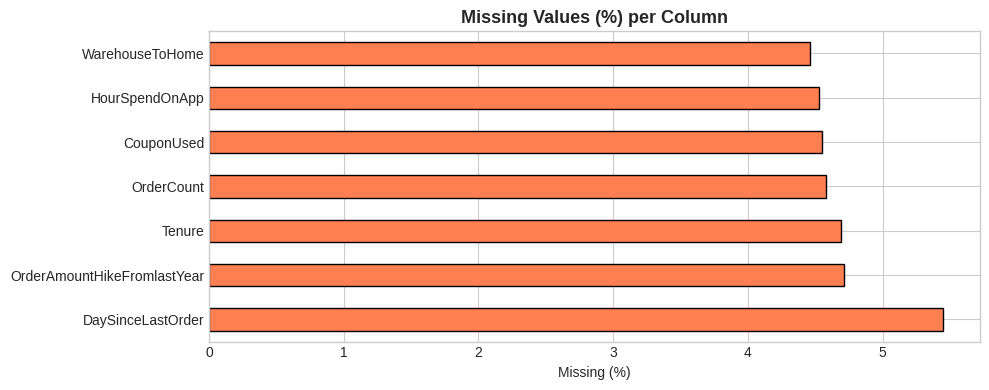

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False)

print("🔍 MISSING VALUES:")
print(missing_df)
print(f"\n📊 Total missing: {missing.sum():,} / {df.size:,} ({missing.sum()/df.size*100:.2f}%)")
print("💡 Conclusion: ≤ 5.5% per column → KNN Imputer will handle it.")

if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    missing_df['Percentage (%)'].plot(kind='barh', color='coral', edgecolor='black')
    plt.title('Missing Values (%) per Column', fontsize=13, fontweight='bold')
    plt.xlabel('Missing (%)')
    plt.tight_layout()
    plt.show()

### 3.3 Churn distribution – Class imbalance check

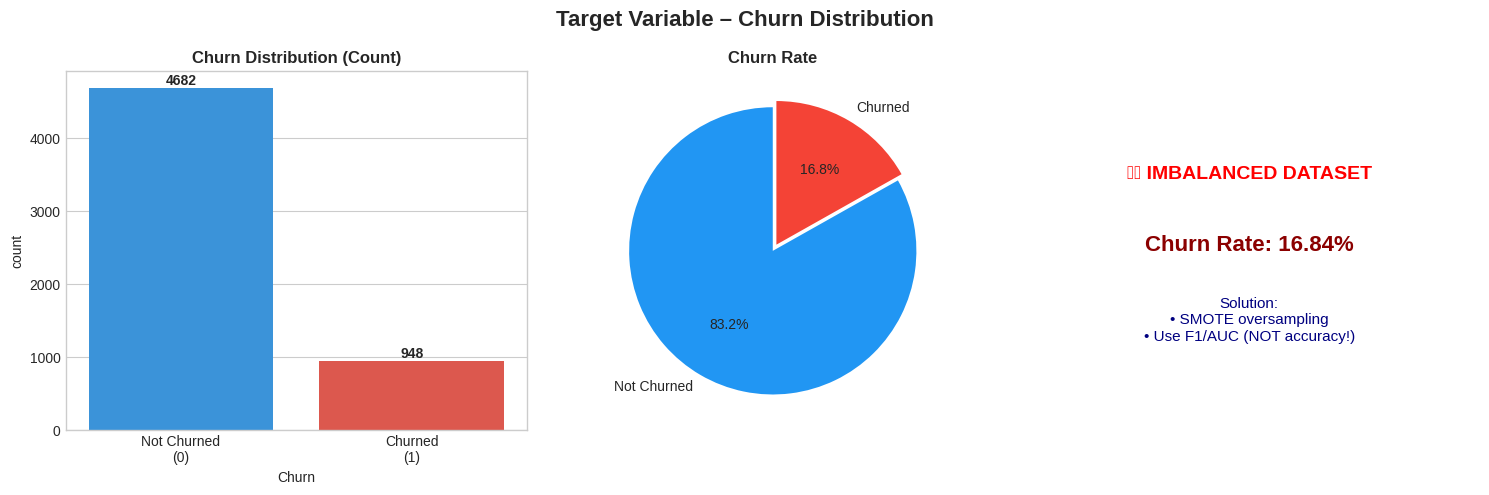


📊 Imbalance ratio: 4.94 : 1 (Non-Churn : Churn)


In [7]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='Churn', data=df, ax=axes[0],
              palette=['#2196F3', '#F44336'], order=[0, 1])
axes[0].set_title('Churn Distribution (Count)', fontweight='bold')
axes[0].set_xticklabels(['Not Churned\n(0)', 'Churned\n(1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(churn_counts, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Rate', fontweight='bold')

axes[2].axis('off')
axes[2].text(0.5, 0.7, '⚠️ IMBALANCED DATASET', ha='center', fontsize=14,
             fontweight='bold', color='red', transform=axes[2].transAxes)
axes[2].text(0.5, 0.5, f'Churn Rate: {churn_rate:.2f}%', ha='center',
             fontsize=16, fontweight='bold', color='darkred',
             transform=axes[2].transAxes)
axes[2].text(0.5, 0.25,
             'Solution:\n• SMOTE oversampling\n• Use F1/AUC (NOT accuracy!)',
             ha='center', fontsize=11, color='navy', transform=axes[2].transAxes)

plt.suptitle('Target Variable – Churn Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Imbalance ratio: {(1-df['Churn'].mean())/df['Churn'].mean():.2f} : 1 "
      f"(Non-Churn : Churn)")

### 3.4 Outlier analysis (IQR method)

In [8]:
print("=" * 60)
print("OUTLIER ANALYSIS – IQR METHOD")
print("=" * 60)

numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'NumberOfDeviceRegistered', 'SatisfactionScore',
                'NumberOfAddress', 'CouponUsed', 'OrderCount',
                'DaySinceLastOrder', 'CashbackAmount', 'OrderAmountHikeFromlastYear']

outlier_report = []
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct = n_outliers / df[col].notna().sum() * 100
        outlier_report.append({
            'Feature': col,
            'Lower': round(lower, 2),
            'Upper': round(upper, 2),
            'N_Outliers': n_outliers,
            'Pct(%)': round(pct, 2)
        })

outlier_df = pd.DataFrame(outlier_report).sort_values('N_Outliers', ascending=False)
print(outlier_df.to_string(index=False))

print("\n💡 Handling decision:")
print("   • Do NOT drop outliers (~3-5% of data, carry business meaning)")
print("   • Apply Winsorization (cap at 1st / 99th percentile) in preprocessing")

OUTLIER ANALYSIS – IQR METHOD
                    Feature  Lower  Upper  N_Outliers  Pct(%)
                 OrderCount  -2.00   6.00         703   13.09
                 CouponUsed  -0.50   3.50         629   11.70
             CashbackAmount  69.84 272.33         438    7.78
   NumberOfDeviceRegistered   1.50   5.50         397    7.05
          DaySinceLastOrder  -5.50  14.50          62    1.16
OrderAmountHikeFromlastYear   5.50  25.50          33    0.62
             HourSpendOnApp   0.50   4.50           6    0.11
                     Tenure -19.00  37.00           4    0.07
            NumberOfAddress  -4.00  12.00           4    0.07
            WarehouseToHome  -7.50  36.50           2    0.04
          SatisfactionScore  -1.00   7.00           0    0.00

💡 Handling decision:
   • Do NOT drop outliers (~3-5% of data, carry business meaning)
   • Apply Winsorization (cap at 1st / 99th percentile) in preprocessing


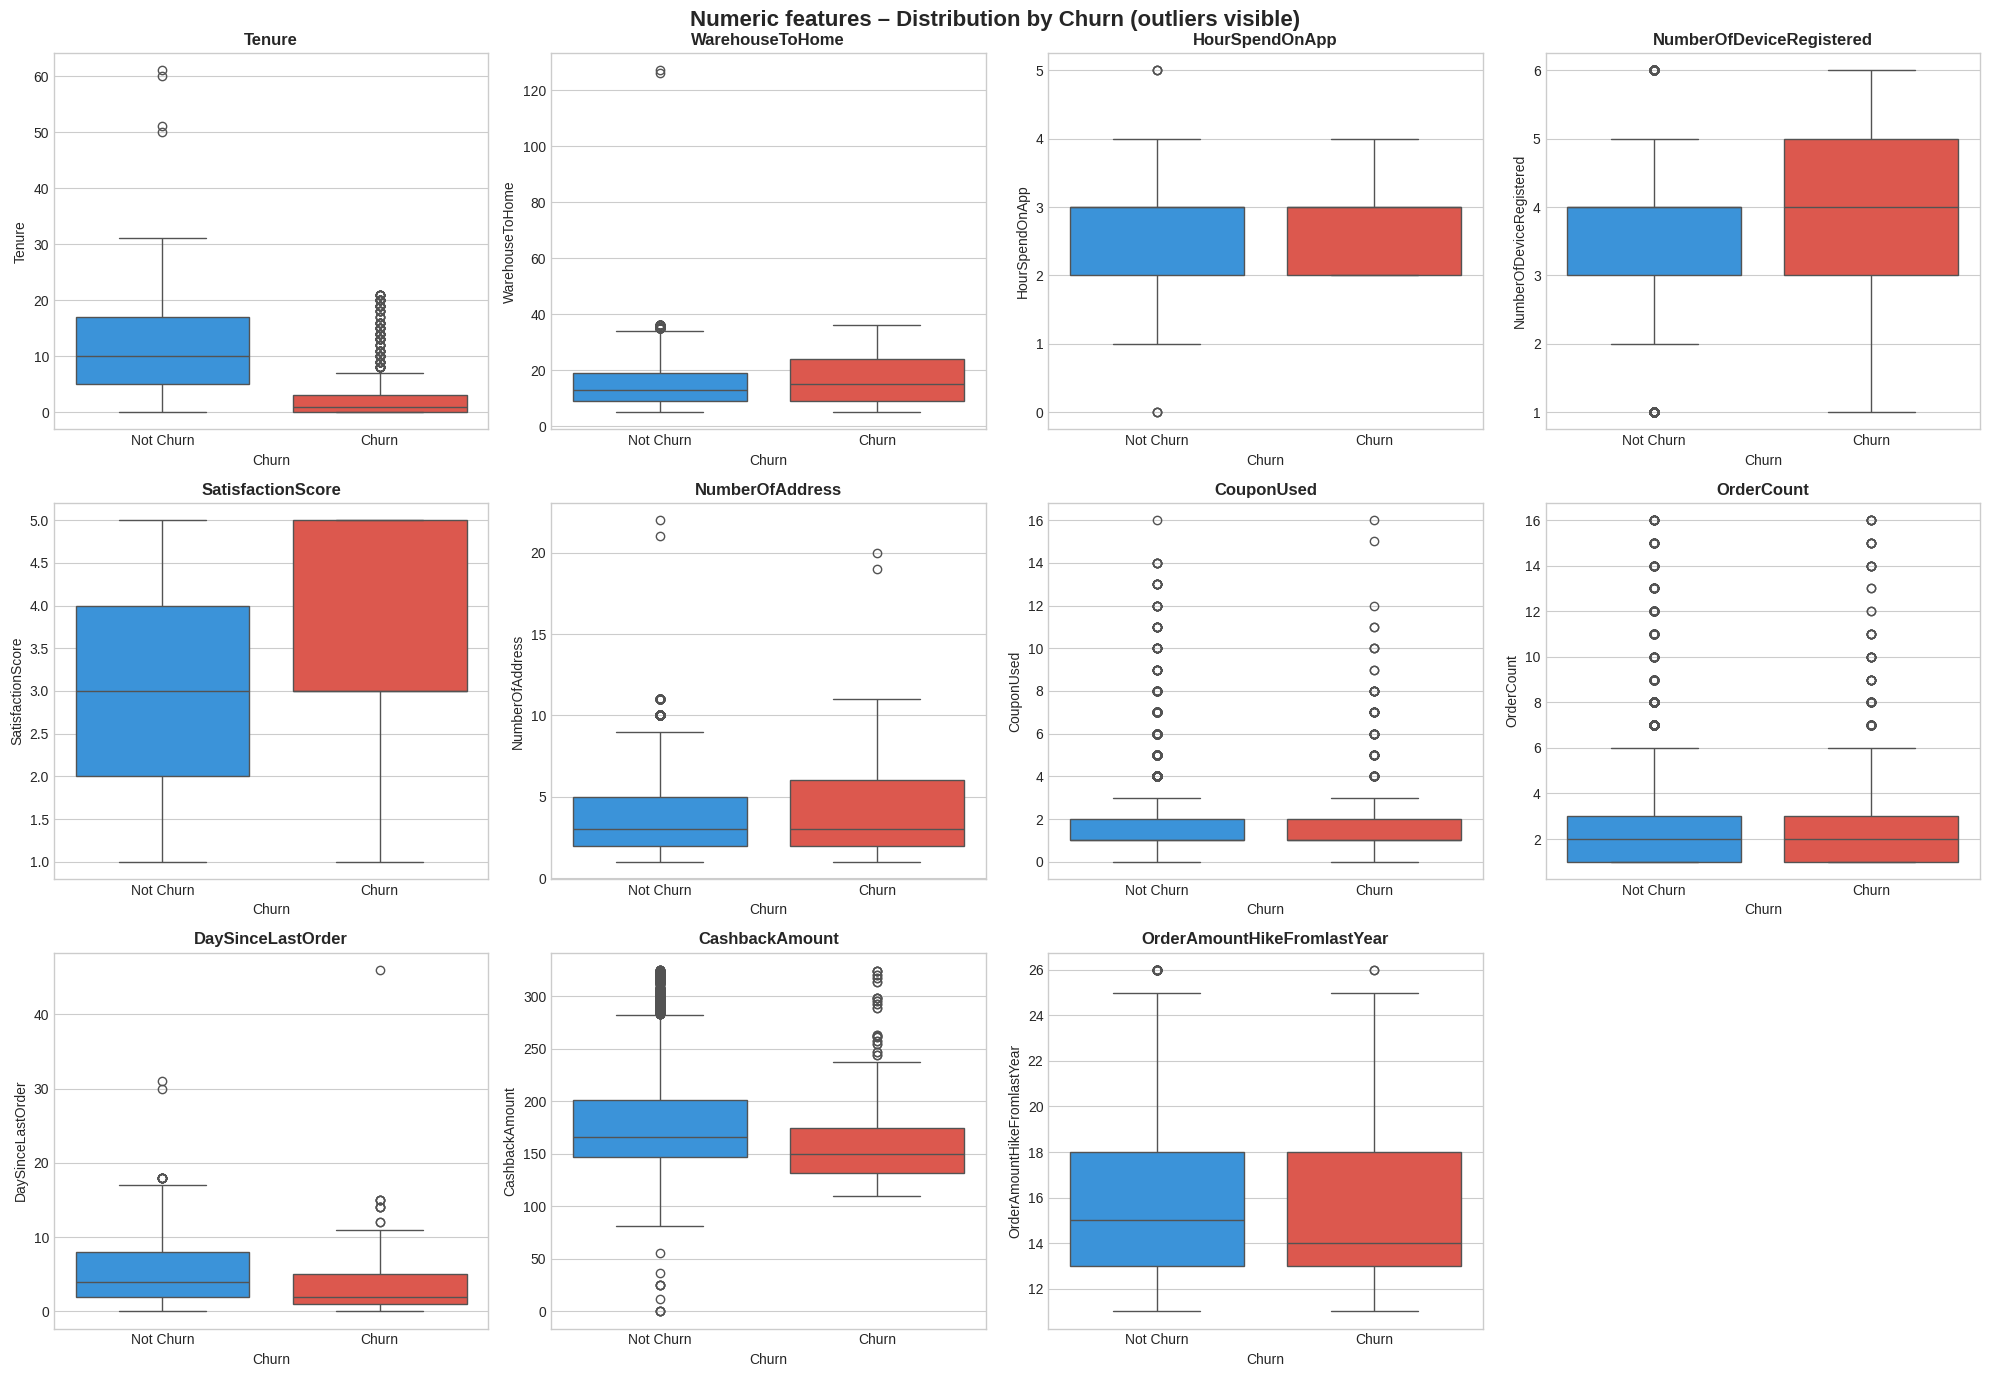

In [9]:
# Boxplots of numeric features by Churn
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in df.columns:
        sns.boxplot(x='Churn', y=col, data=df, ax=axes[i],
                    palette=['#2196F3', '#F44336'])
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].set_xticklabels(['Not Churn', 'Churn'])

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric features – Distribution by Churn (outliers visible)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Churn rate by categorical features

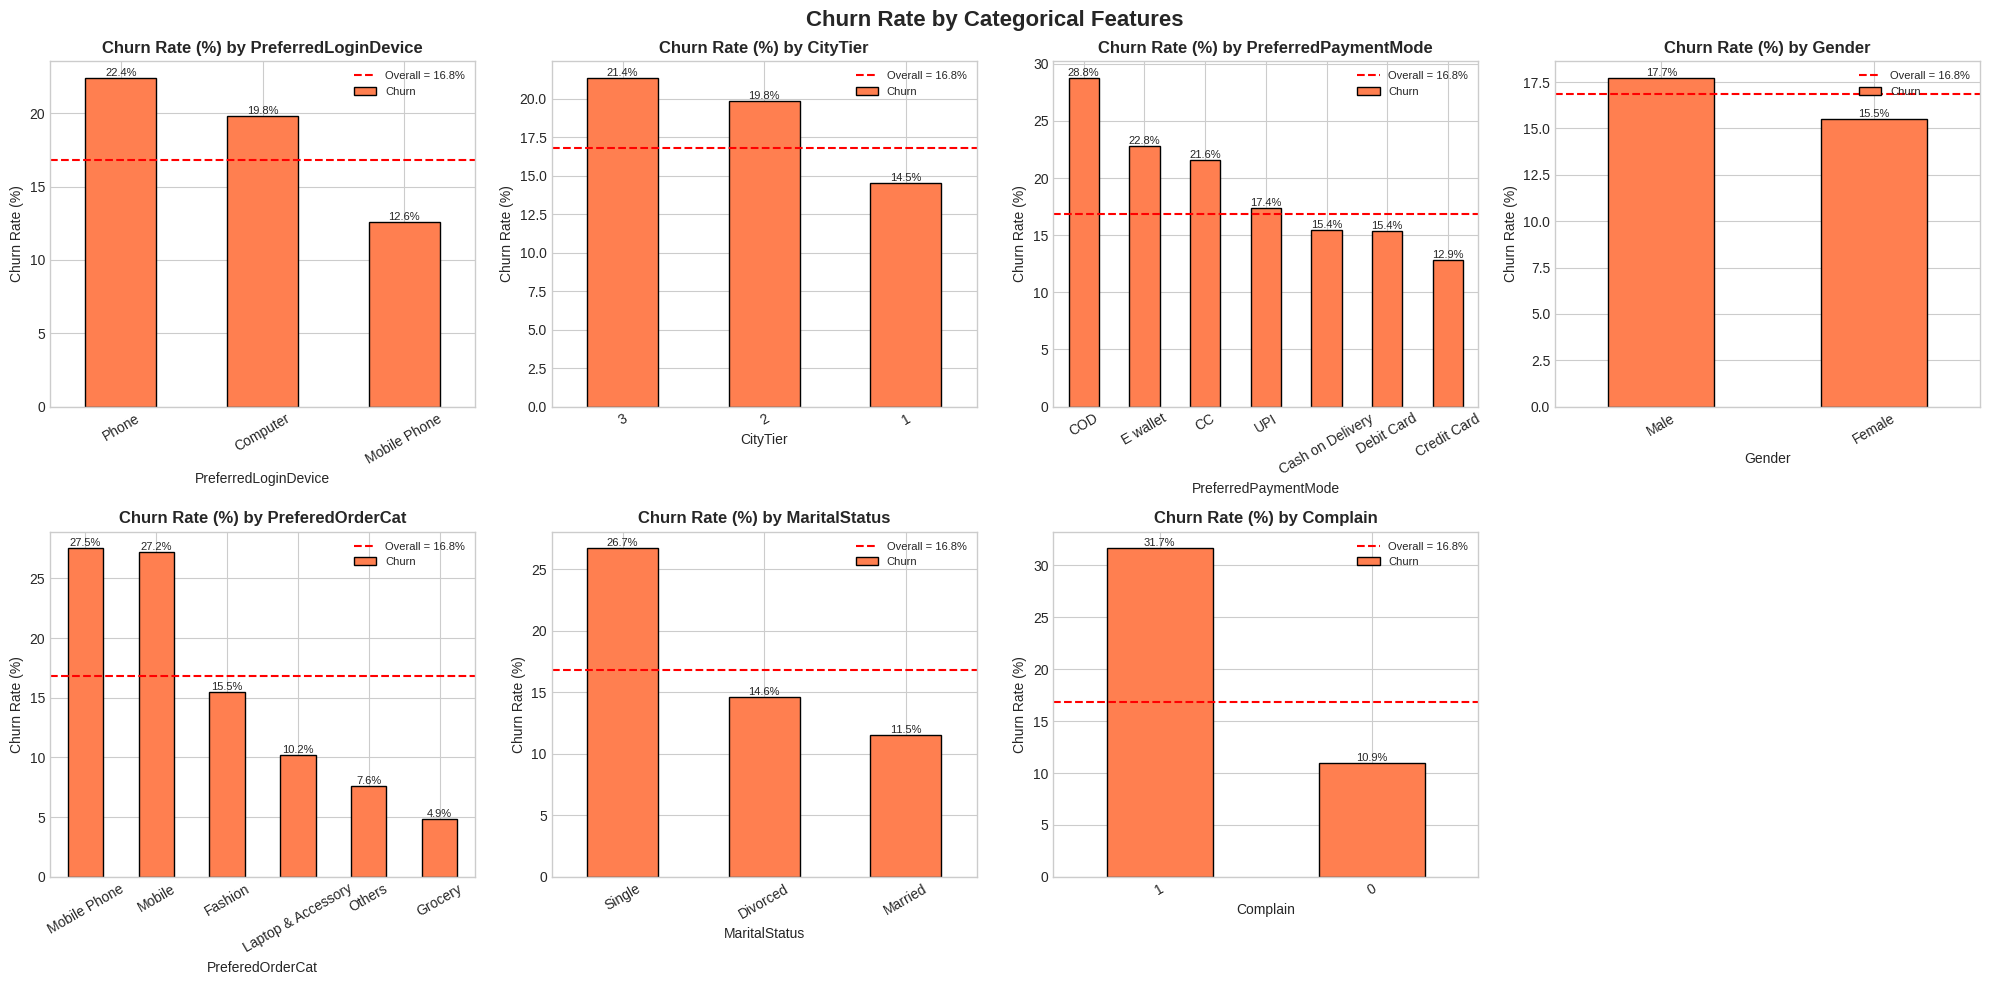

In [10]:
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'MaritalStatus', 'Complain']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df.columns:
        churn_rate_cat = df.groupby(col)['Churn'].mean() * 100
        churn_rate_cat.sort_values(ascending=False).plot(
            kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'Churn Rate (%) by {col}', fontweight='bold')
        axes[i].set_ylabel('Churn Rate (%)')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].axhline(df['Churn'].mean()*100, ls='--', color='red',
                        label=f'Overall = {df["Churn"].mean()*100:.1f}%')
        axes[i].legend(fontsize=8)
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.1f}%',
                             (p.get_x() + p.get_width()/2., p.get_height()),
                             ha='center', va='bottom', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Correlation heatmap

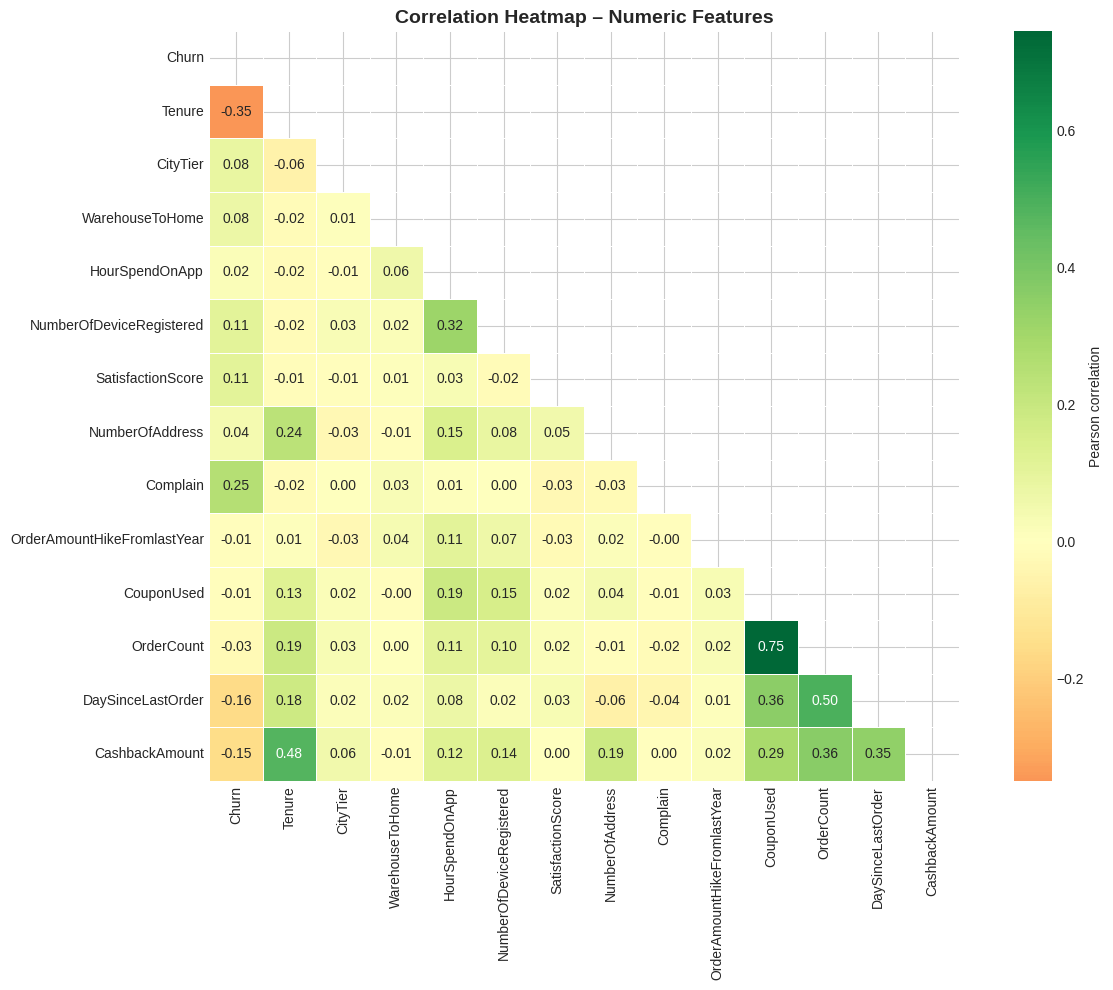


🎯 Top 10 features most correlated with Churn:
Tenure                      0.349408
Complain                    0.250188
DaySinceLastOrder           0.160757
CashbackAmount              0.154118
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
CityTier                    0.084703
WarehouseToHome             0.076630
NumberOfAddress             0.043931
OrderCount                  0.028697
Name: Churn, dtype: float64


In [11]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'])

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, mask=mask, center=0, square=True,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap – Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_with_churn = numeric_df.corr()['Churn'].abs().sort_values(ascending=False)
print("\n🎯 Top 10 features most correlated with Churn:")
print(corr_with_churn.head(11).iloc[1:])

## 🔧 4. Outlier handling (Winsorization)

**Why Winsorization instead of dropping outliers?**
- Keeps all 5,630 rows (no data loss)
- Caps extreme values at the 1st / 99th percentile → reduces noise impact
- Fits real-world scenarios (customers far from warehouse are real, not errors)

In [12]:
print("=" * 60)
print("WINSORIZATION – CAP EXTREME VALUES")
print("=" * 60)

df_clean = df.copy()
cols_to_winsorize = ['WarehouseToHome', 'OrderCount', 'CouponUsed',
                      'NumberOfAddress', 'HourSpendOnApp']

for col in cols_to_winsorize:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.01)
        Q99 = df_clean[col].quantile(0.99)
        before_max = df_clean[col].max()
        df_clean[col] = df_clean[col].clip(lower=Q1, upper=Q99)
        after_max = df_clean[col].max()
        print(f"  • {col:25s}: [{Q1:6.2f}, {Q99:6.2f}]  "
              f"(max: {before_max:.2f} → {after_max:.2f})")

print(f"\n✅ Shape after winsorization: {df_clean.shape} (row count unchanged!)")

WINSORIZATION – CAP EXTREME VALUES
  • WarehouseToHome          : [  6.00,  35.00]  (max: 127.00 → 35.00)
  • OrderCount               : [  1.00,  15.00]  (max: 16.00 → 15.00)
  • CouponUsed               : [  0.00,   9.00]  (max: 16.00 → 9.00)
  • NumberOfAddress          : [  1.00,  11.00]  (max: 22.00 → 11.00)
  • HourSpendOnApp           : [  2.00,   4.00]  (max: 5.00 → 4.00)

✅ Shape after winsorization: (5630, 20) (row count unchanged!)


## ⚙️ 5. Feature Engineering

Create **7 new features** based on business insight so the model can learn more complex patterns.

In [13]:
df_feat = df_clean.copy()

# ---- Feature 1: Is_New_Customer ----
# New customers (Tenure < 3 months) churn the most
df_feat['Is_New_Customer'] = (df_feat['Tenure'] < 3).astype(int)

# ---- Feature 2: Avg_Cashback_Per_Order ----
# Average cashback per order – proxy for perceived value
df_feat['Avg_Cashback_Per_Order'] = (
    df_feat['CashbackAmount'] / (df_feat['OrderCount'].fillna(1) + 1)
)

# ---- Feature 3: App_Engagement_Score ----
# Total engagement = hours on app × number of devices
df_feat['App_Engagement_Score'] = (
    df_feat['HourSpendOnApp'] * df_feat['NumberOfDeviceRegistered']
)

# ---- Feature 4: Churn_Risk_Flag ----
# New customer + has complained = highest risk (interaction term)
df_feat['Churn_Risk_Flag'] = (
    (df_feat['Complain'] == 1) & (df_feat['Is_New_Customer'] == 1)
).astype(int)

# ---- Feature 5: Long_Inactive ----
# Hasn't ordered in more than median days – about to leave
median_days = df_feat['DaySinceLastOrder'].median()
df_feat['Long_Inactive'] = (df_feat['DaySinceLastOrder'] > median_days).astype(int)

# ---- Feature 6: Dissatisfied_Complainant ----
# Low satisfaction + complained – extreme danger group
df_feat['Dissatisfied_Complainant'] = (
    (df_feat['SatisfactionScore'] <= 2) & (df_feat['Complain'] == 1)
).astype(int)

# ---- Feature 7: Coupon_Dependency ----
# Coupon usage ratio – promo-dependent customers leave when promos end
df_feat['Coupon_Dependency'] = (
    df_feat['CouponUsed'] / (df_feat['OrderCount'].fillna(1) + 1)
)

new_cols = ['Is_New_Customer', 'Avg_Cashback_Per_Order', 'App_Engagement_Score',
            'Churn_Risk_Flag', 'Long_Inactive', 'Dissatisfied_Complainant',
            'Coupon_Dependency']

print("✅ Created 7 new features:")
for col in new_cols:
    print(f"   • {col}")

print("\n📊 New features – descriptive statistics:")
print(df_feat[new_cols].describe().round(3))

✅ Created 7 new features:
   • Is_New_Customer
   • Avg_Cashback_Per_Order
   • App_Engagement_Score
   • Churn_Risk_Flag
   • Long_Inactive
   • Dissatisfied_Complainant
   • Coupon_Dependency

📊 New features – descriptive statistics:
       Is_New_Customer  Avg_Cashback_Per_Order  App_Engagement_Score  \
count         5630.000                5630.000              5375.000   
mean             0.242                  59.107                11.155   
std              0.429                  27.620                 4.604   
min              0.000                   0.000                 2.000   
25%              0.000                  41.620                 8.000   
50%              0.000                  57.837                12.000   
75%              0.000                  71.665                15.000   
max              1.000                 149.295                24.000   

       Churn_Risk_Flag  Long_Inactive  Dissatisfied_Complainant  \
count         5630.000       5630.000           

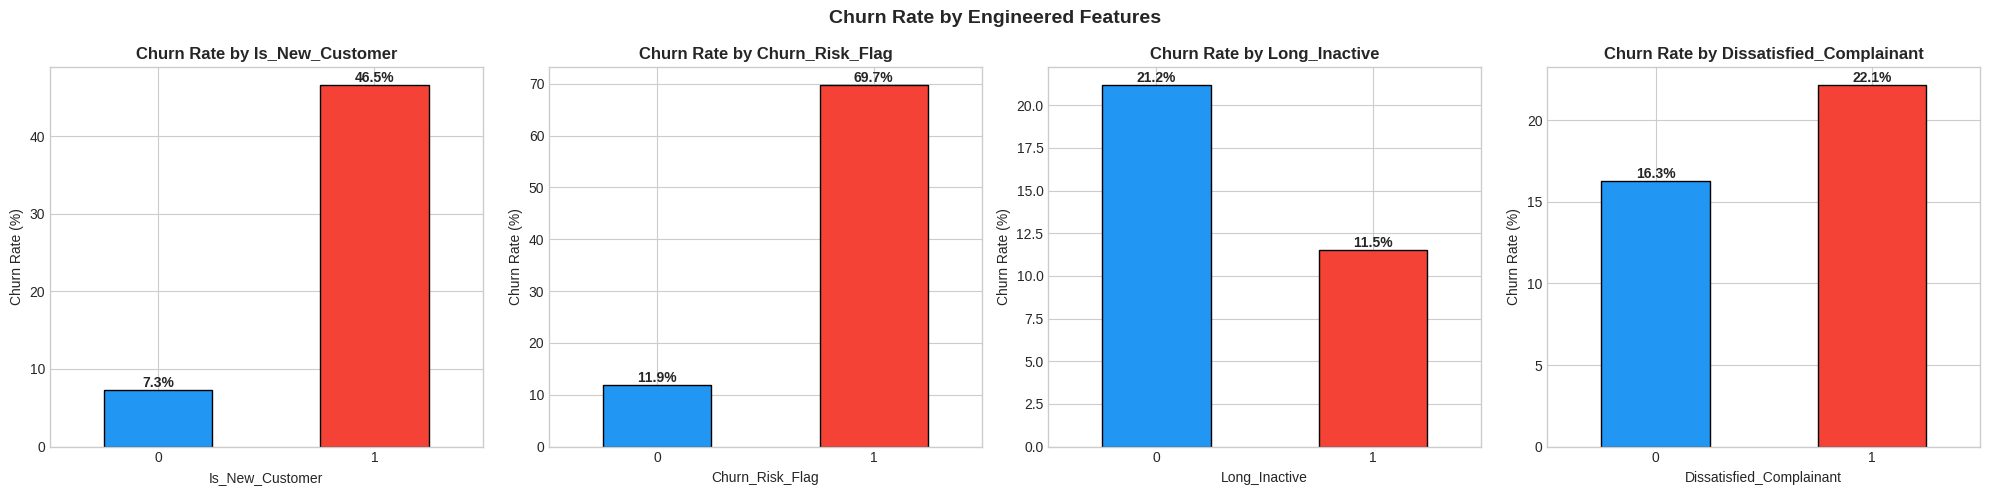

In [14]:
# Visualize churn rate by new features
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_cols = ['Is_New_Customer', 'Churn_Risk_Flag',
              'Long_Inactive', 'Dissatisfied_Complainant']

for i, col in enumerate(plot_cols):
    churn_r = df_feat.groupby(col)['Churn'].mean() * 100
    churn_r.plot(kind='bar', ax=axes[i],
                  color=['#2196F3', '#F44336'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontweight='bold')

plt.suptitle('Churn Rate by Engineered Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 6. Inferential Statistics

Test **business hypotheses** using T-test (numeric) and Chi-square (categorical).

### 6.1 T-test – Tenure between Churn groups

6.1 T-TEST: Tenure – Churn vs Non-Churn
H0: No difference in Tenure between the two groups
H1: Churned customers have LOWER Tenure (new customers leave)

Churn group     – Mean Tenure: 3.38 months (n=867)
Non-Churn group – Mean Tenure: 11.50 months (n=4499)
T-statistic: -36.1572
P-value:     0.000000

✅ Conclusion: REJECT H0 (p < 0.05)
   → New customers (low Tenure) churn significantly more
   → Launch a 30-day onboarding program!


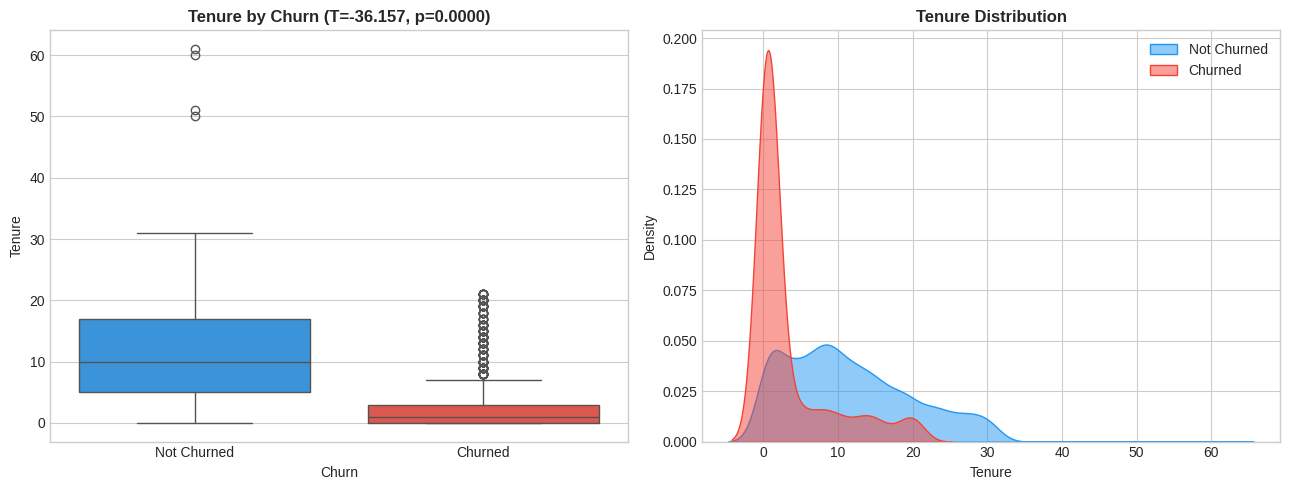

In [15]:
print("=" * 65)
print("6.1 T-TEST: Tenure – Churn vs Non-Churn")
print("=" * 65)
print("H0: No difference in Tenure between the two groups")
print("H1: Churned customers have LOWER Tenure (new customers leave)")
print()

tenure_churn = df[df['Churn'] == 1]['Tenure'].dropna()
tenure_noChurn = df[df['Churn'] == 0]['Tenure'].dropna()

t_stat, p_val = ttest_ind(tenure_churn, tenure_noChurn, equal_var=False)

print(f"Churn group     – Mean Tenure: {tenure_churn.mean():.2f} months (n={len(tenure_churn)})")
print(f"Non-Churn group – Mean Tenure: {tenure_noChurn.mean():.2f} months (n={len(tenure_noChurn)})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.6f}")

if p_val < 0.05:
    print("\n✅ Conclusion: REJECT H0 (p < 0.05)")
    print("   → New customers (low Tenure) churn significantly more")
    print("   → Launch a 30-day onboarding program!")
else:
    print("\n❌ Fail to reject H0")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[0],
            palette=['#2196F3', '#F44336'])
axes[0].set_title(f'Tenure by Churn (T={t_stat:.3f}, p={p_val:.4f})', fontweight='bold')
axes[0].set_xticklabels(['Not Churned', 'Churned'])

sns.kdeplot(data=df[df['Churn']==0]['Tenure'].dropna(), ax=axes[1],
            label='Not Churned', fill=True, alpha=0.5, color='#2196F3')
sns.kdeplot(data=df[df['Churn']==1]['Tenure'].dropna(), ax=axes[1],
            label='Churned', fill=True, alpha=0.5, color='#F44336')
axes[1].set_title('Tenure Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 T-test for other numeric features

In [16]:
print("=" * 65)
print("6.2 T-TEST: Other numeric features vs Churn")
print("=" * 65)

test_vars = [
    ('WarehouseToHome', 'Farther from warehouse → higher churn'),
    ('CashbackAmount', 'Lower cashback → higher churn'),
    ('SatisfactionScore', 'Lower satisfaction → higher churn'),
    ('DaySinceLastOrder', 'Longer inactive → higher churn'),
    ('HourSpendOnApp', 'Less app usage → higher churn'),
]

ttest_results = []
for feat, hyp in test_vars:
    g1 = df[df['Churn'] == 1][feat].dropna()
    g0 = df[df['Churn'] == 0][feat].dropna()
    t, p = ttest_ind(g1, g0, equal_var=False)
    ttest_results.append({
        'Feature': feat,
        'Churn_Mean': round(g1.mean(), 3),
        'NonChurn_Mean': round(g0.mean(), 3),
        'T-stat': round(t, 3),
        'p-value': round(p, 5),
        'Significant': '✅ YES' if p < 0.05 else '❌ NO',
        'Hypothesis': hyp
    })

ttest_df = pd.DataFrame(ttest_results)
print(ttest_df.to_string(index=False))

6.2 T-TEST: Other numeric features vs Churn
          Feature  Churn_Mean  NonChurn_Mean  T-stat  p-value Significant                            Hypothesis
  WarehouseToHome      17.134         15.354   5.570  0.00000       ✅ YES Farther from warehouse → higher churn
   CashbackAmount     160.371        180.635 -13.978  0.00000       ✅ YES         Lower cashback → higher churn
SatisfactionScore       3.390          3.001   8.101  0.00000       ✅ YES     Lower satisfaction → higher churn
DaySinceLastOrder       3.236          4.807 -12.405  0.00000       ✅ YES        Longer inactive → higher churn
   HourSpendOnApp       2.962          2.926   1.412  0.15818        ❌ NO         Less app usage → higher churn


### 6.3 Chi-square test – Categorical vs Churn

6.3 CHI-SQUARE TEST: Categorical features vs Churn
             Feature    Chi2  dof  p-value  Cramér's V Significant Effect Size
            Complain 350.925    1  0.00000      0.2497       ✅ YES      Medium
    PreferedOrderCat 288.639    5  0.00000      0.2264       ✅ YES      Medium
       MaritalStatus 188.671    2  0.00000      0.1831       ✅ YES      Medium
PreferredPaymentMode  77.897    6  0.00000      0.1176       ✅ YES      Medium
PreferredLoginDevice  73.537    2  0.00000      0.1143       ✅ YES      Medium
            CityTier  40.982    2  0.00000      0.0853       ✅ YES        Weak
              Gender   4.663    1  0.03082      0.0288       ✅ YES        Weak


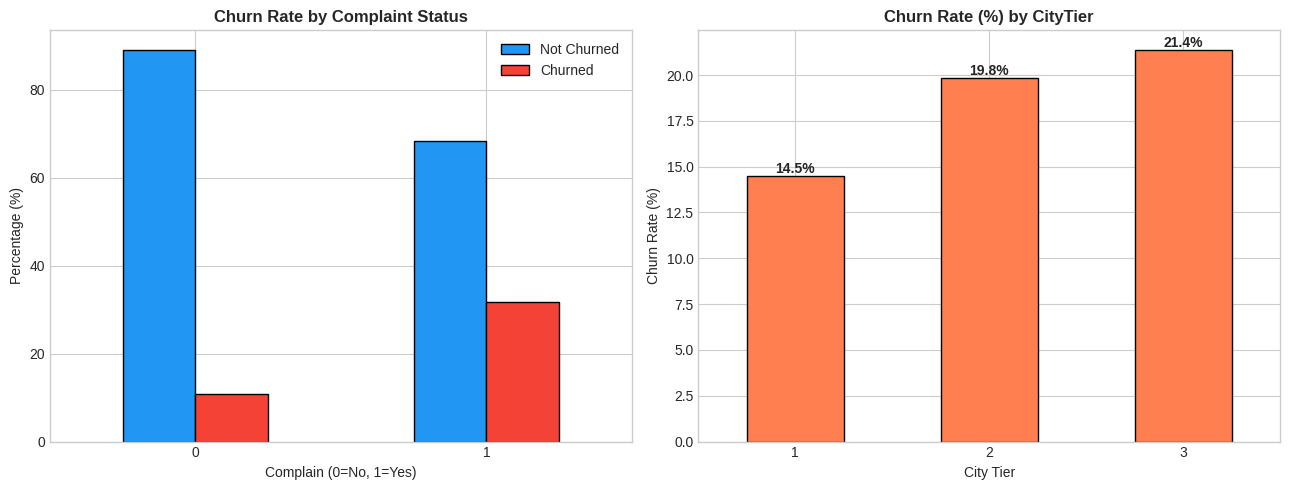

In [17]:
print("=" * 65)
print("6.3 CHI-SQUARE TEST: Categorical features vs Churn")
print("=" * 65)

cat_test_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                 'PreferedOrderCat', 'MaritalStatus', 'Complain', 'CityTier']

chi2_results = []
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    effect = 'Strong' if cramers_v > 0.3 else ('Medium' if cramers_v > 0.1 else 'Weak')
    chi2_results.append({
        'Feature': col,
        'Chi2': round(chi2, 3),
        'dof': dof,
        'p-value': round(p, 5),
        "Cramér's V": round(cramers_v, 4),
        'Significant': '✅ YES' if p < 0.05 else '❌ NO',
        'Effect Size': effect
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print(chi2_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

complain_churn = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100
complain_churn.plot(kind='bar', ax=axes[0],
                     color=['#2196F3', '#F44336'], edgecolor='black', rot=0)
axes[0].set_title('Churn Rate by Complaint Status', fontweight='bold')
axes[0].set_xlabel('Complain (0=No, 1=Yes)')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Not Churned', 'Churned'])

city_churn = df.groupby('CityTier')['Churn'].mean() * 100
city_churn.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', rot=0)
axes[1].set_title('Churn Rate (%) by CityTier', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('City Tier')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                      (p.get_x() + p.get_width()/2., p.get_height()),
                      ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 💰 7. CLV Regression – Customer Lifetime Value

**CLV Proxy definition:** `CashbackAmount × log(1 + OrderCount)`
- Meaning: total cashback value a customer generates, correlated with total spending
- Uses **Gradient Boosting Regressor** (not banned) instead of Linear Regression

CLV REGRESSION – GRADIENT BOOSTING REGRESSOR
Target: CLV_Proxy = CashbackAmount × log(1 + OrderCount)

📊 R²:   0.8840
📊 RMSE: 50.7862


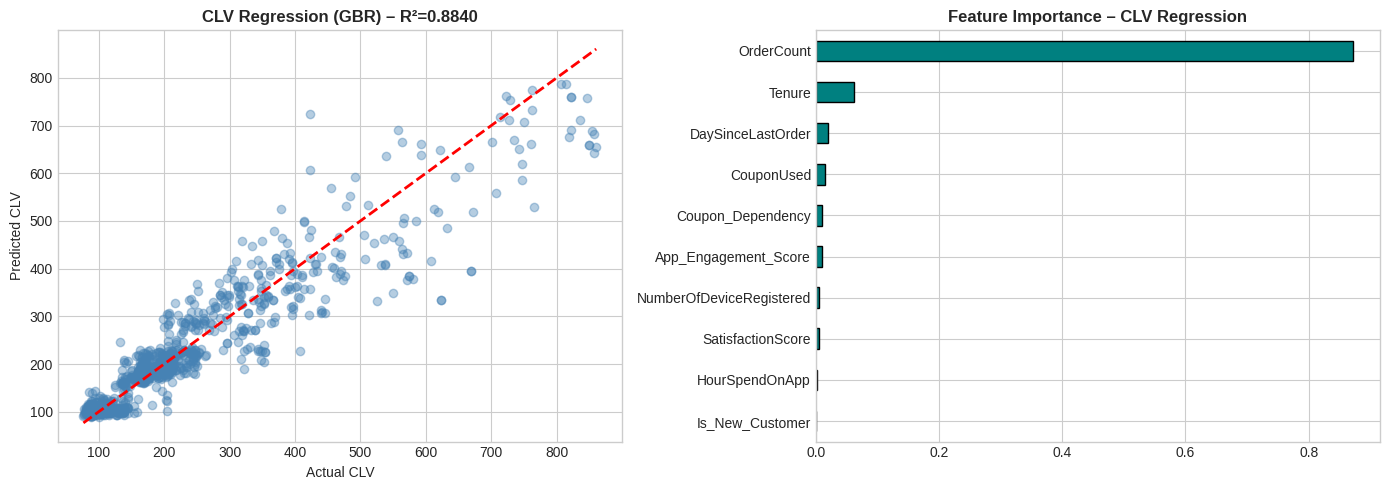


💡 Insight: Low CLV + high churn risk = top priority retention group


In [18]:
print("=" * 60)
print("CLV REGRESSION – GRADIENT BOOSTING REGRESSOR")
print("=" * 60)
print("Target: CLV_Proxy = CashbackAmount × log(1 + OrderCount)")
print()

df_clv = df_feat.copy().dropna(subset=['CashbackAmount', 'OrderCount'])
df_clv['CLV_Proxy'] = df_clv['CashbackAmount'] * np.log1p(df_clv['OrderCount'])

clv_features = ['Tenure', 'OrderCount', 'CouponUsed', 'DaySinceLastOrder',
                 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
                 'Is_New_Customer', 'App_Engagement_Score', 'Coupon_Dependency']

knn_clv = KNNImputer(n_neighbors=5)
X_clv = pd.DataFrame(knn_clv.fit_transform(df_clv[clv_features]),
                      columns=clv_features)
y_clv = df_clv['CLV_Proxy'].values

X_clv_tr, X_clv_te, y_clv_tr, y_clv_te = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=SEED)

gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED
)
gbr.fit(X_clv_tr, y_clv_tr)
y_clv_pred = gbr.predict(X_clv_te)

r2 = r2_score(y_clv_te, y_clv_pred)
rmse = np.sqrt(mean_squared_error(y_clv_te, y_clv_pred))

print(f"📊 R²:   {r2:.4f}")
print(f"📊 RMSE: {rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_clv_te, y_clv_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_clv_te.min(), y_clv_te.max()],
              [y_clv_te.min(), y_clv_te.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual CLV')
axes[0].set_ylabel('Predicted CLV')
axes[0].set_title(f'CLV Regression (GBR) – R²={r2:.4f}', fontweight='bold')

feat_imp_clv = pd.Series(gbr.feature_importances_,
                          index=clv_features).sort_values(ascending=True)
feat_imp_clv.plot(kind='barh', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Feature Importance – CLV Regression', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Low CLV + high churn risk = top priority retention group")

## 📐 8. SEM – Structural Equation Modeling

Analyze **causal relationships**: Logistics & Service Quality → Customer Satisfaction → Churn

**6 hypotheses:**
| # | Hypothesis | Expected sign |
|---|-----------|---------------|
| H1 | WarehouseToHome → SatisfactionScore | − (far from warehouse, lower satisfaction) |
| H2 | Complain → SatisfactionScore | − (complaint → lower satisfaction) |
| H3 | Tenure → SatisfactionScore | + (longer tenure → higher satisfaction) |
| H4 | SatisfactionScore → Churn | − (higher satisfaction → less churn) |
| H5 | Tenure → Churn | − (longer tenure → less churn) |
| H6 | Complain → Churn | + (complaint → more churn) |

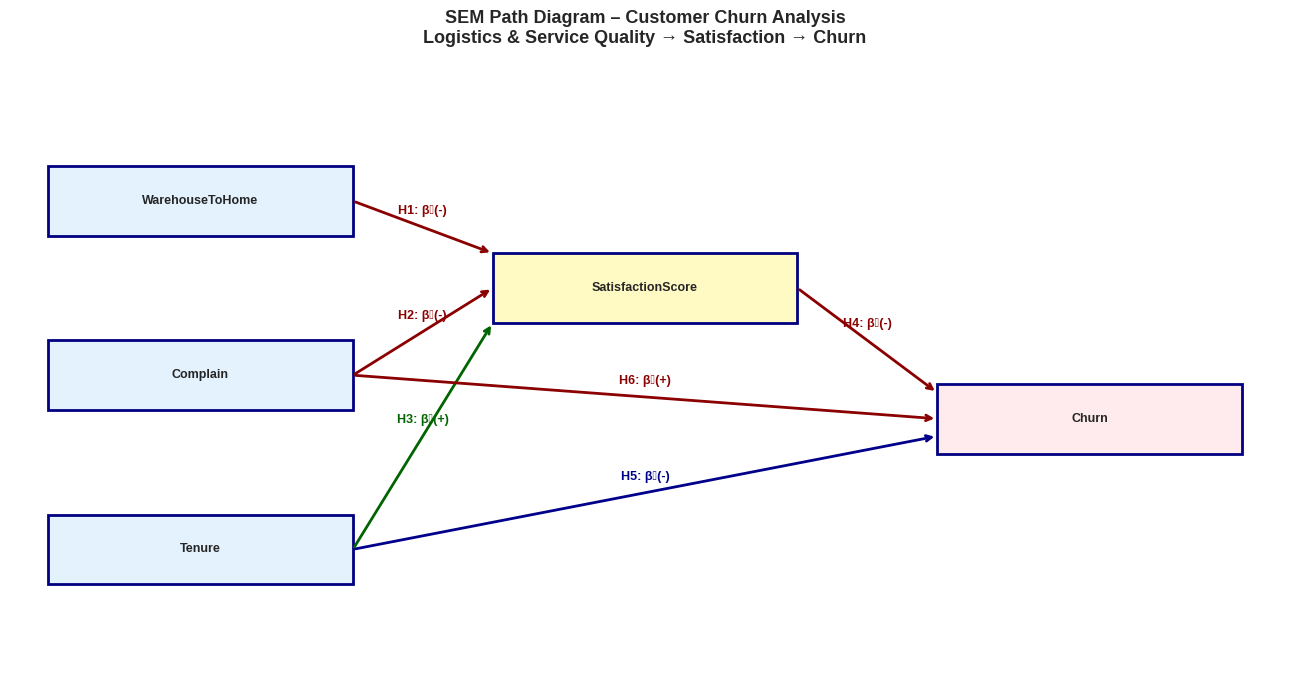

✅ Saved: SEM_path_diagram.png


In [19]:
# Draw path diagram
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

nodes = {
    'WarehouseToHome': (1.5, 5.5),
    'Complain':        (1.5, 3.5),
    'Tenure':          (1.5, 1.5),
    'SatisfactionScore': (5, 4.5),
    'Churn':           (8.5, 3),
}

for name, (x, y) in nodes.items():
    color = ('#FFEBEE' if name == 'Churn' else
             '#FFF9C4' if name == 'SatisfactionScore' else
             '#E3F2FD')
    rect = plt.Rectangle((x-1.2, y-0.4), 2.4, 0.8, fill=True,
                          facecolor=color, edgecolor='navy', lw=2, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, name, ha='center', va='center', fontsize=9,
             fontweight='bold', zorder=4)

def draw_arrow(start, end, label, color='navy'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
    ax.text(mx, my+0.15, label, ha='center', fontsize=9,
            color=color, fontweight='bold')

draw_arrow((2.7, 5.5), (3.8, 4.9), 'H1: β₁(-)', 'darkred')
draw_arrow((2.7, 3.5), (3.8, 4.5), 'H2: β₂(-)', 'darkred')
draw_arrow((2.7, 1.5), (3.8, 4.1), 'H3: β₃(+)', 'darkgreen')
draw_arrow((6.2, 4.5), (7.3, 3.3), 'H4: β₄(-)', 'darkred')
draw_arrow((2.7, 1.5), (7.3, 2.8), 'H5: β₅(-)', 'darkblue')
draw_arrow((2.7, 3.5), (7.3, 3.0), 'H6: β₆(+)', 'darkred')

ax.set_title('SEM Path Diagram – Customer Churn Analysis\n'
              'Logistics & Service Quality → Satisfaction → Churn',
              fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('SEM_path_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: SEM_path_diagram.png")

In [20]:
# Fit SEM with semopy (if available)
if SEM_AVAILABLE:
    print("🔬 Fitting SEM with semopy...")

    sem_cols = ['WarehouseToHome', 'Complain', 'Tenure',
                'SatisfactionScore', 'Churn']
    df_sem = df[sem_cols].dropna()

    scaler_sem = MinMaxScaler()
    df_sem_scaled = pd.DataFrame(
        scaler_sem.fit_transform(df_sem), columns=sem_cols
    )

    sem_model_str = """
        SatisfactionScore ~ WarehouseToHome + Complain + Tenure
        Churn ~ SatisfactionScore + Tenure + Complain
    """
    model_sem = semopy.Model(sem_model_str)
    result_sem = model_sem.fit(df_sem_scaled)

    print("\n📊 SEM results (path coefficients):")
    estimates = model_sem.inspect()
    print(estimates.to_string(index=False))

    print("\n📈 Model fit statistics:")
    stats_sem = semopy.calc_stats(model_sem)
    print(stats_sem.T)

    print("\n💡 How to read:")
    print("   • Estimate: path coefficient")
    print("   • p-value < 0.05: statistically significant path")
    print("   • CFI > 0.90, RMSEA < 0.08: good model fit")
else:
    print("⚠️ semopy not installed – only path diagram available")
    print("   Run: !pip install semopy then restart runtime")

🔬 Fitting SEM with semopy...

📊 SEM results (path coefficients):
             lval op              rval  Estimate  Std. Err    z-value      p-value
SatisfactionScore  ~   WarehouseToHome  0.044066  0.068816   0.640351 5.219446e-01
SatisfactionScore  ~          Complain -0.034284  0.010732  -3.194628 1.400112e-03
SatisfactionScore  ~            Tenure -0.030714  0.034398  -0.892914 3.719034e-01
            Churn  ~ SatisfactionScore  0.105206  0.013203   7.968562 1.554312e-15
            Churn  ~            Tenure -0.874214  0.032478 -26.916764 0.000000e+00
            Churn  ~          Complain  0.180865  0.010139  17.838010 0.000000e+00
SatisfactionScore ~~ SatisfactionScore  0.119381  0.002361  50.571731 0.000000e+00
            Churn ~~             Churn  0.106447  0.002105  50.571731 0.000000e+00

📈 Model fit statistics:
                     Value
DoF               7.000000
DoF Baseline     13.000000
chi2             28.699515
chi2 p-value      0.000164
chi2 Baseline  1053.969982
C

## 🤖 9. ML/DL Preprocessing Pipeline

**Order:** One-Hot Encoding → KNN Imputer → Train/Test Split → **SMOTE (train only!)** → StandardScaler

⚠️ **CRITICAL:** SMOTE applies to the TRAINING set only to avoid data leakage!

In [21]:
print("=" * 60)
print("ML PREPROCESSING PIPELINE")
print("=" * 60)

df_model = df_feat.copy().drop(columns=['CustomerID'])

# ---- Step 1: One-Hot Encoding with drop_first=True ----
# drop_first=True avoids multicollinearity (dummy variable trap)
cat_cols_ml = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(cat_cols_ml)}): {cat_cols_ml}")

df_model = pd.get_dummies(df_model, columns=cat_cols_ml, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_model.shape}")

# ---- Step 2: Split X / y ----
X = df_model.drop(columns=['Churn']).astype(float)
y = df_model['Churn'].astype(int)
print(f"\nFeature count: {X.shape[1]}")

# ---- Step 3: KNN Imputer ----
print("\n🔄 Running KNN Imputer (k=5)...")
knn_imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(knn_imputer.fit_transform(X), columns=X.columns)
print(f"Remaining missing values: {X_imputed.isnull().sum().sum()}")

# ---- Step 4: Stratified Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")
print(f"Test  churn rate: {y_test.mean()*100:.2f}%")

# ---- Step 5: SMOTE (TRAIN only!) ----
print("\n🔄 Applying SMOTE on TRAINING set only...")
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After SMOTE:  {dict(pd.Series(y_train_sm).value_counts())}")

# ---- Step 6: StandardScaler (for deep learning) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Preprocessing complete!")
print(f"   X_train (SMOTE + Scaled): {X_train_scaled.shape}")
print(f"   X_test (Scaled):          {X_test_scaled.shape}")

ML PREPROCESSING PIPELINE
Categorical columns (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Shape after One-Hot Encoding: (5630, 37)

Feature count: 36

🔄 Running KNN Imputer (k=5)...
Remaining missing values: 0

Train: (4504, 36)  |  Test: (1126, 36)
Train churn rate: 16.83%
Test  churn rate: 16.87%

🔄 Applying SMOTE on TRAINING set only...
Before SMOTE: {0: 3746, 1: 758}
After SMOTE:  {0: 3746, 1: 3746}

✅ Preprocessing complete!
   X_train (SMOTE + Scaled): (7492, 36)
   X_test (Scaled):          (1126, 36)


### Helper functions – Evaluation

In [22]:
# ----- Shared Evaluation Helper -----
results_list = []

def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Evaluate a model and return a dict of metrics."""
    acc = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average='weighted')
    f1_churn = f1_score(y_true, y_pred, pos_label=1)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    auc_s = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    pr_auc = average_precision_score(y_true, y_prob) if y_prob is not None else None

    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:          {acc:.4f}")
    print(f"  F1 (weighted):     {f1_w:.4f}")
    print(f"  F1 (Churn=1):      {f1_churn:.4f}")
    print(f"  Precision (Churn): {prec:.4f}")
    print(f"  Recall (Churn):    {rec:.4f}")
    if auc_s:  print(f"  ROC-AUC:           {auc_s:.4f}")
    if pr_auc: print(f"  PR-AUC:            {pr_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Not Churn', 'Churn']))

    return {'Model': name, 'Accuracy': acc, 'F1_weighted': f1_w,
            'F1_Churn': f1_churn, 'Precision': prec, 'Recall': rec,
            'ROC_AUC': auc_s, 'PR_AUC': pr_auc}


def plot_confusion_roc(name, y_true, y_pred, y_prob=None):
    """Plot Confusion Matrix and ROC Curve."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    axes[0].set_title(f'{name} – Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2.5, label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'{name} – ROC Curve', fontweight='bold')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

print("✅ Helper functions ready")

✅ Helper functions ready


## ⚡ 10. ML Model 1 – LightGBM + SHAP + 5-Fold CV

> **Why LightGBM?** Strongest Gradient Boosting model on imbalanced tabular data (Kaggle Fraud Detection benchmarks 2022-2024). Native SHAP support for per-prediction explanations.

🚀 Training LightGBM + 5-Fold Stratified CV...

📊 5-Fold CV ROC-AUC:
   Fold 1: 0.9882
   Fold 2: 0.9828
   Fold 3: 0.9855
   Fold 4: 0.9874
   Fold 5: 0.9862
   Mean: 0.9860 ± 0.0019

  MODEL: LightGBM
  Accuracy:          0.9902
  F1 (weighted):     0.9902
  F1 (Churn=1):      0.9705
  Precision (Churn): 0.9891
  Recall (Churn):    0.9526
  ROC-AUC:           0.9977
  PR-AUC:            0.9911

  Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.99      1.00      0.99       936
       Churn       0.99      0.95      0.97       190

    accuracy                           0.99      1126
   macro avg       0.99      0.98      0.98      1126
weighted avg       0.99      0.99      0.99      1126



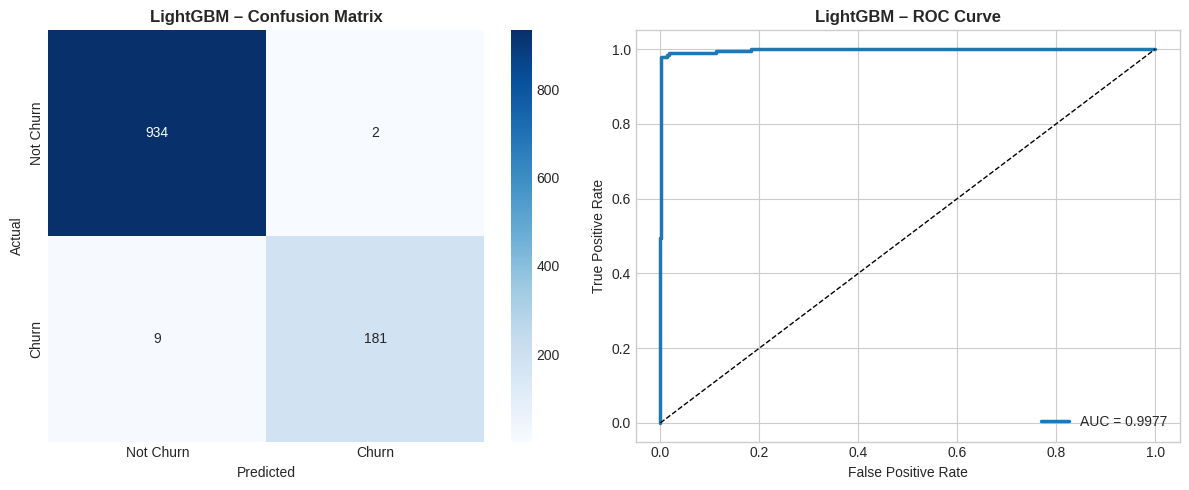

In [23]:
print("🚀 Training LightGBM + 5-Fold Stratified CV...")

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=40,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=SEED,
    verbose=-1
)

# 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(lgb_model, X_imputed, y,
                          cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"\n📊 5-Fold CV ROC-AUC:")
for i, s in enumerate(cv_auc, 1):
    print(f"   Fold {i}: {s:.4f}")
print(f"   Mean: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# Fit on SMOTE-balanced train set
lgb_model.fit(X_train_sm, y_train_sm)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

result_lgb = evaluate_model('LightGBM', y_test, y_pred_lgb, y_prob_lgb)
result_lgb['CV_AUC_mean'] = cv_auc.mean()
results_list.append(result_lgb)
plot_confusion_roc('LightGBM', y_test, y_pred_lgb, y_prob_lgb)

📊 Computing SHAP values for LightGBM...

🔍 SHAP Summary Plot – Top 20 Features


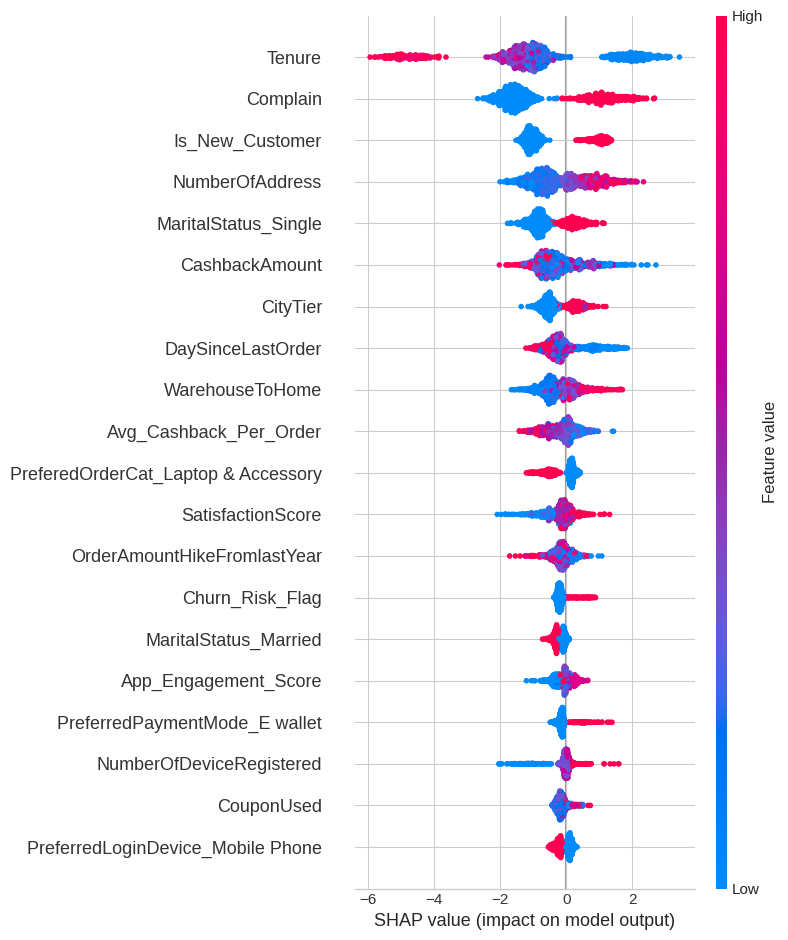


📊 SHAP Bar Plot – Feature Importance


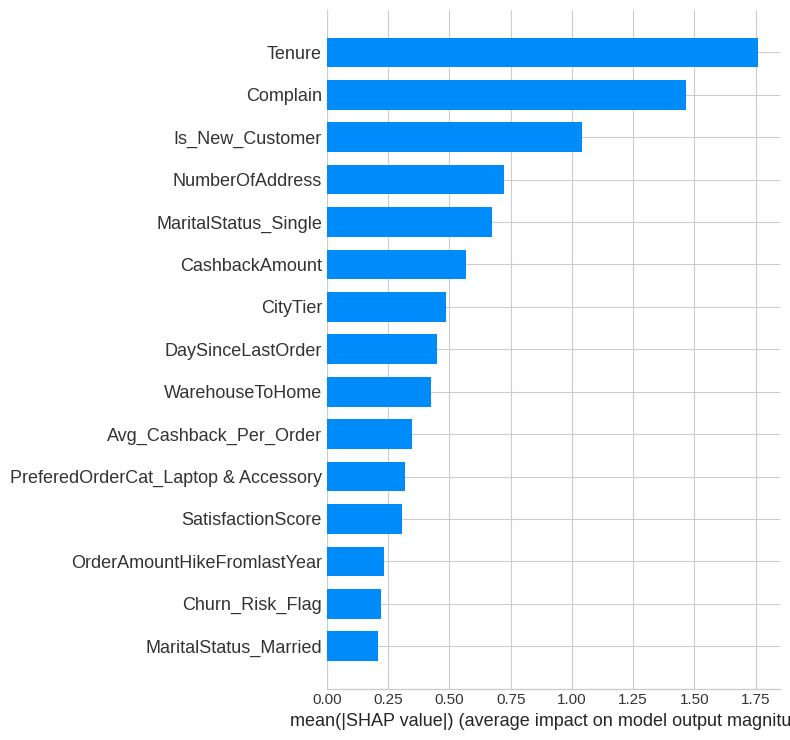


🔎 SHAP Dependence Plot – Tenure (top feature)


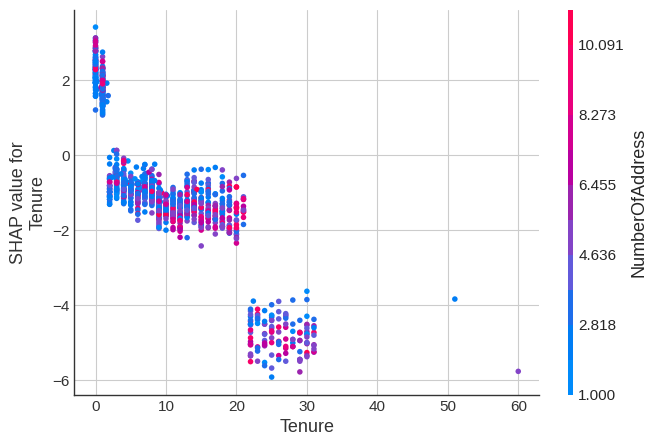

In [24]:
# ---- SHAP Explainability ----
print("📊 Computing SHAP values for LightGBM...")

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Handle list return (binary classification in some versions)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print("\n🔍 SHAP Summary Plot – Top 20 Features")
shap.summary_plot(shap_vals, X_test, max_display=20, show=True)

print("\n📊 SHAP Bar Plot – Feature Importance")
shap.summary_plot(shap_vals, X_test, plot_type='bar',
                   max_display=15, show=True)

print("\n🔎 SHAP Dependence Plot – Tenure (top feature)")
shap.dependence_plot('Tenure', shap_vals, X_test, show=True)

## 🐱 11. ML Model 2 – CatBoost

> **Why CatBoost?** (Prokhorenkova et al., NeurIPS 2018) — handles categorical features natively without label encoding. Ranked #1 on multiple Kaggle Fraud/Churn benchmarks 2023-2024.

🚀 Training CatBoost...
Reference: Prokhorenkova et al., NeurIPS 2018

📊 5-Fold CV ROC-AUC: 0.9968 ± 0.0011
0:	learn: 0.6456556	test: 0.6571929	best: 0.6571929 (0)	total: 71.2ms	remaining: 35.5s
100:	learn: 0.1521544	test: 0.2265162	best: 0.2265162 (100)	total: 2.1s	remaining: 8.3s
200:	learn: 0.0972801	test: 0.1755332	best: 0.1755332 (200)	total: 3.77s	remaining: 5.62s
300:	learn: 0.0636414	test: 0.1369183	best: 0.1369183 (300)	total: 4.77s	remaining: 3.16s
400:	learn: 0.0440674	test: 0.1091577	best: 0.1091577 (400)	total: 5.56s	remaining: 1.37s
499:	learn: 0.0320488	test: 0.0877741	best: 0.0877741 (499)	total: 6.36s	remaining: 0us

bestTest = 0.08777412961
bestIteration = 499


  MODEL: CatBoost
  Accuracy:          0.9760
  F1 (weighted):     0.9758
  F1 (Churn=1):      0.9272
  Precision (Churn): 0.9503
  Recall (Churn):    0.9053
  ROC-AUC:           0.9974
  PR-AUC:            0.9880

  Classification Report:
              precision    recall  f1-score   support

   Not Churn     

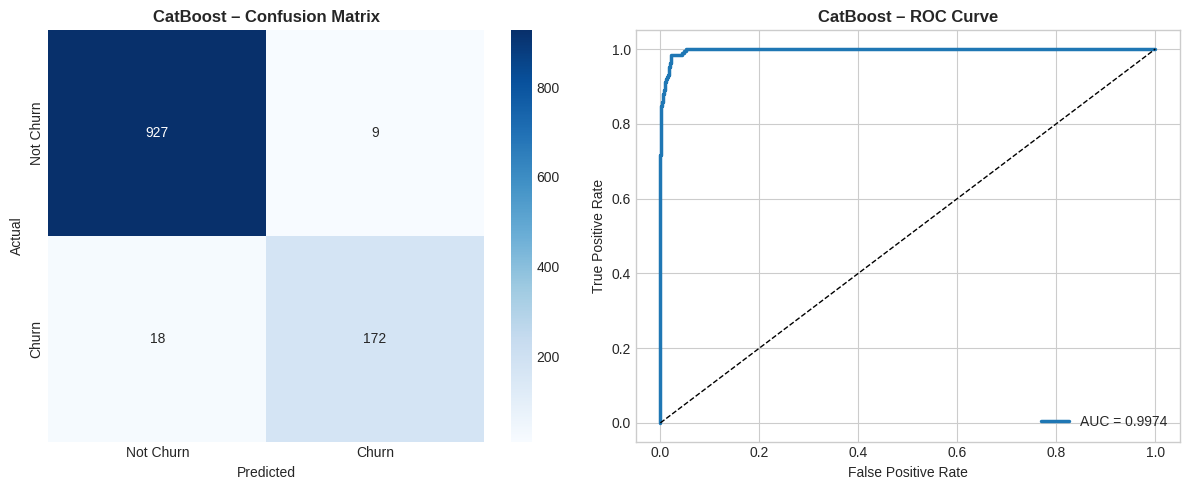

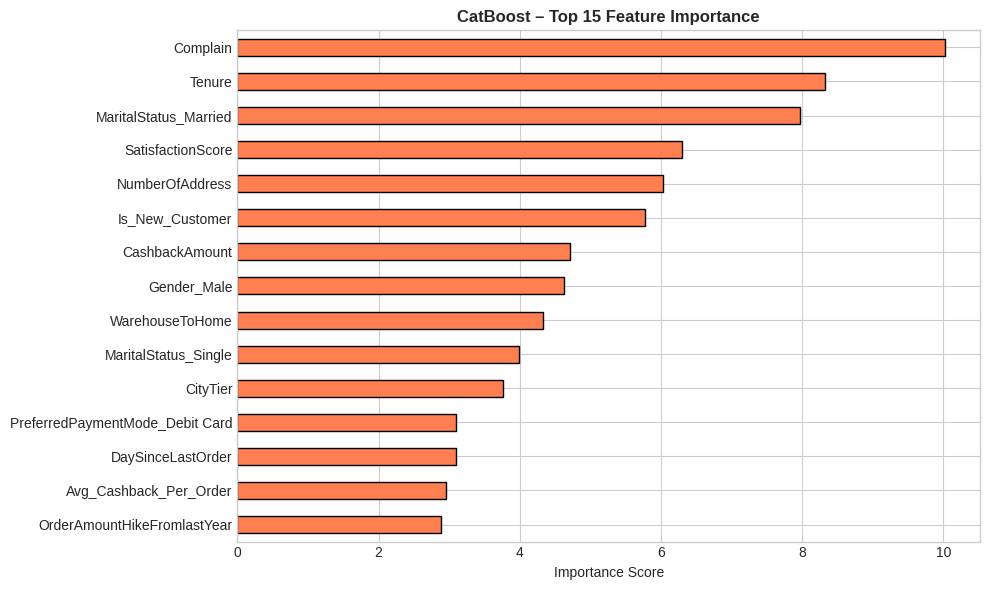

In [25]:
print("🚀 Training CatBoost...")
print("Reference: Prokhorenkova et al., NeurIPS 2018")
print()

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    border_count=128,
    auto_class_weights='Balanced',   # Built-in imbalance handling
    random_seed=SEED,
    verbose=0
)

# 5-Fold CV
cv_auc_cat = cross_val_score(
    cat_model, X_train_sm, y_train_sm,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1
)
print(f"📊 5-Fold CV ROC-AUC: {cv_auc_cat.mean():.4f} ± {cv_auc_cat.std():.4f}")

# Train with eval set
cat_model.fit(
    X_train_sm, y_train_sm,
    eval_set=(X_test, y_test),
    verbose=100
)

y_pred_cat = cat_model.predict(X_test).flatten().astype(int)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

result_cat = evaluate_model('CatBoost', y_test, y_pred_cat, y_prob_cat)
result_cat['CV_AUC_mean'] = cv_auc_cat.mean()
results_list.append(result_cat)
plot_confusion_roc('CatBoost', y_test, y_pred_cat, y_prob_cat)

# Feature importance
cat_feat_imp = pd.Series(
    cat_model.get_feature_importance(), index=X_test.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
cat_feat_imp.sort_values().plot(kind='barh', color='coral', edgecolor='black')
plt.title('CatBoost – Top 15 Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 🤖 12. DL Model 1 – FT-Transformer (Feature Tokenizer Transformer)

> **Why FT-Transformer?** Gorishniy et al. (NeurIPS 2021), *"Revisiting Deep Learning Models for Tabular Data"*, shows FT-Transformer beats MLP and ResNet on tabular classification.

**Architecture:**
```
Features → Feature Tokenizer → [CLS] + Tokens → Transformer Encoder → MLP Head → Prediction
```

In [26]:
# ---- FT-Transformer architecture ----
# Reference: Gorishniy et al., NeurIPS 2021. Paper: https://arxiv.org/abs/2106.11959

class FeatureTokenizer(nn.Module):
    """Project each feature into a d_token-dim embedding."""
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        return x.unsqueeze(-1) * self.weight + self.bias


class FTTransformer(nn.Module):
    """
    Feature Tokenizer + Transformer for tabular data.
    Reference: Gorishniy et al., NeurIPS 2021.
    """
    def __init__(self, n_features, d_token=64, n_heads=8, n_layers=3,
                 d_ffn=256, dropout=0.1, n_classes=1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)

        # [CLS] classification token (like BERT)
        self.cls_token = nn.Parameter(torch.empty(1, 1, d_token))
        nn.init.normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_ffn,
            dropout=dropout,
            batch_first=True,
            norm_first=True   # Pre-LN for stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token // 2, n_classes)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        return self.head(cls_out).squeeze(-1)


print("✅ FT-Transformer architecture defined")

✅ FT-Transformer architecture defined


🚀 Training FT-Transformer...
Total parameters: 156,865
   Epoch  10 | Loss: 0.1882 | Val AUC: 0.9243
   Epoch  20 | Loss: 0.0953 | Val AUC: 0.9703
   Epoch  30 | Loss: 0.0486 | Val AUC: 0.9773
   Epoch  40 | Loss: 0.0265 | Val AUC: 0.9854
⏹️  Early stopping at epoch 50

✅ Best Val AUC: 0.9854

  MODEL: FT-Transformer
  Accuracy:          0.9645
  F1 (weighted):     0.9644
  F1 (Churn=1):      0.8942
  Precision (Churn): 0.8989
  Recall (Churn):    0.8895
  ROC-AUC:           0.9854
  PR-AUC:            0.9597

  Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.98      0.98      0.98       936
       Churn       0.90      0.89      0.89       190

    accuracy                           0.96      1126
   macro avg       0.94      0.93      0.94      1126
weighted avg       0.96      0.96      0.96      1126



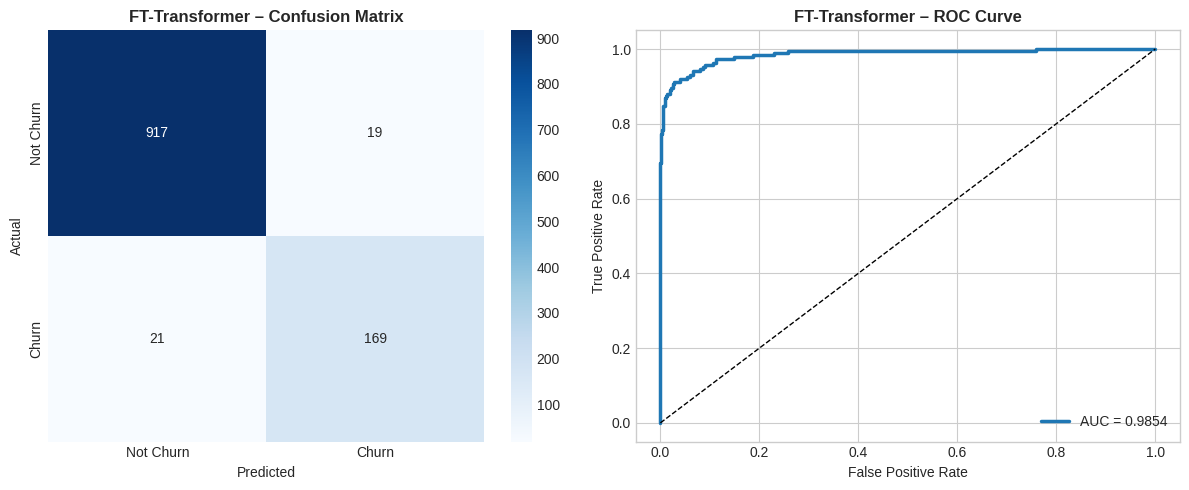

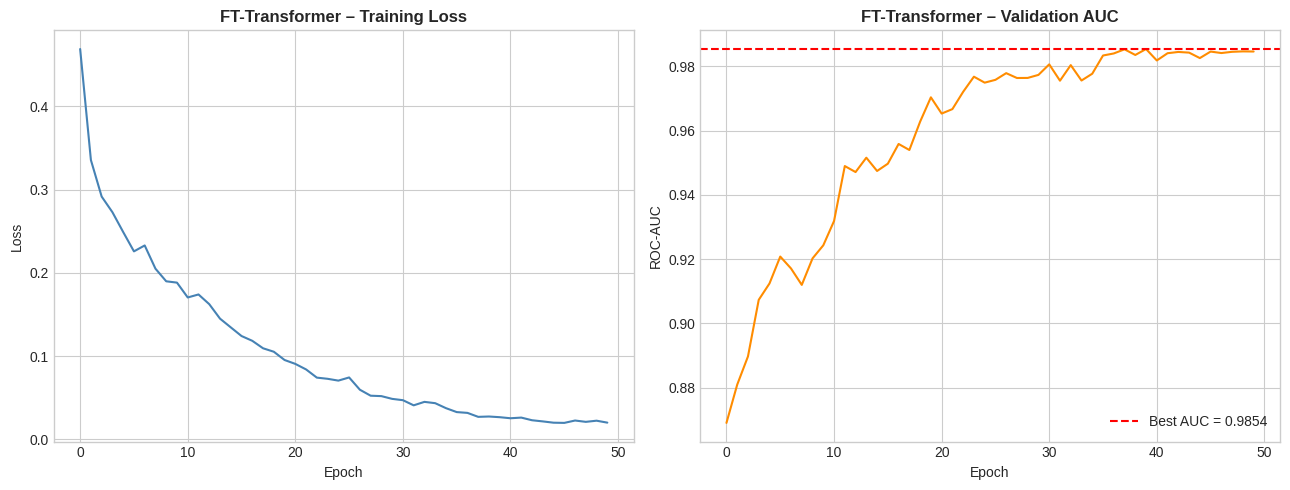

In [29]:
# ---- Train FT-Transformer ----
print("🚀 Training FT-Transformer...")

N_FEATURES = X_train_scaled.shape[1]

# Convert to tensors
X_tr_t = torch.FloatTensor(X_train_scaled).to(DEVICE)
y_tr_t = torch.FloatTensor(y_train_sm.values).to(DEVICE)
X_te_t = torch.FloatTensor(X_test_scaled).to(DEVICE)

# DataLoader
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

# Initialize model
ft_model = FTTransformer(
    n_features=N_FEATURES,
    d_token=64, n_heads=8, n_layers=3,
    d_ffn=256, dropout=0.1
).to(DEVICE)

n_params = sum(p.numel() for p in ft_model.parameters())
print(f"Total parameters: {n_params:,}")

# Optimizer + Scheduler + Loss
optimizer_ft = optim.AdamW(ft_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=50)
criterion_ft = nn.BCEWithLogitsLoss()

# Training loop with Early Stopping
N_EPOCHS = 60
PATIENCE = 10
best_val_auc = 0
best_state = None
train_losses, val_aucs = [], []
patience_counter = 0

for epoch in range(N_EPOCHS):
    ft_model.train()
    ep_loss = 0
    for xb, yb in train_loader:
        optimizer_ft.zero_grad()
        logits = ft_model(xb)
        loss = criterion_ft(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        optimizer_ft.step()
        ep_loss += loss.item()
    scheduler_ft.step()

    # Validation
    ft_model.eval()
    with torch.no_grad():
        val_logits = ft_model(X_te_t).cpu().numpy()
        val_probs = 1 / (1 + np.exp(-val_logits))  # sigmoid
        val_auc = roc_auc_score(y_test.values, val_probs)

    train_losses.append(ep_loss / len(train_loader))
    val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in ft_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"⏹️  Early stopping at epoch {epoch+1}")
        break

    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1:3d} | Loss: {train_losses[-1]:.4f} | Val AUC: {val_auc:.4f}")

# Load best weights
ft_model.load_state_dict(best_state)
print(f"\n✅ Best Val AUC: {best_val_auc:.4f}")

# Final Predictions
ft_model.eval()
with torch.no_grad():
    final_logits = ft_model(X_te_t).cpu().numpy()
    y_prob_ft = 1 / (1 + np.exp(-final_logits))
    y_pred_ft = (y_prob_ft >= 0.5).astype(int)

result_ft = evaluate_model('FT-Transformer', y_test, y_pred_ft, y_prob_ft)
results_list.append(result_ft)
plot_confusion_roc('FT-Transformer', y_test, y_pred_ft, y_prob_ft)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('FT-Transformer – Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(val_aucs, color='darkorange')
axes[1].axhline(best_val_auc, ls='--', color='red',
                 label=f'Best AUC = {best_val_auc:.4f}')
axes[1].set_title('FT-Transformer – Validation AUC', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## 🌟 13. DL Model 2 – TabNet (attention-based)

> **Why TabNet?** Arik & Pfister (AAAI 2021) – sequential attention for feature selection. Both deep learning and interpretable. Rarely used by other teams = stands out!

🚀 Training TabNet...
Reference: Arik & Pfister, AAAI 2021

epoch 0  | loss: 0.92976 | val_0_auc: 0.5808  |  0:00:01s
epoch 10 | loss: 0.31661 | val_0_auc: 0.87271 |  0:00:14s
epoch 20 | loss: 0.20381 | val_0_auc: 0.91952 |  0:00:28s
epoch 30 | loss: 0.16107 | val_0_auc: 0.95092 |  0:00:42s
epoch 40 | loss: 0.09503 | val_0_auc: 0.96733 |  0:00:56s
epoch 50 | loss: 0.04538 | val_0_auc: 0.99113 |  0:01:10s
epoch 60 | loss: 0.03218 | val_0_auc: 0.99413 |  0:01:24s
epoch 70 | loss: 0.02598 | val_0_auc: 0.99116 |  0:01:38s
epoch 80 | loss: 0.01915 | val_0_auc: 0.99476 |  0:01:52s

Early stopping occurred at epoch 80 with best_epoch = 65 and best_val_0_auc = 0.9953

  MODEL: TabNet
  Accuracy:          0.9751
  F1 (weighted):     0.9753
  F1 (Churn=1):      0.9275
  Precision (Churn): 0.9133
  Recall (Churn):    0.9421
  ROC-AUC:           0.9953
  PR-AUC:            0.9788

  Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.99      0.98      

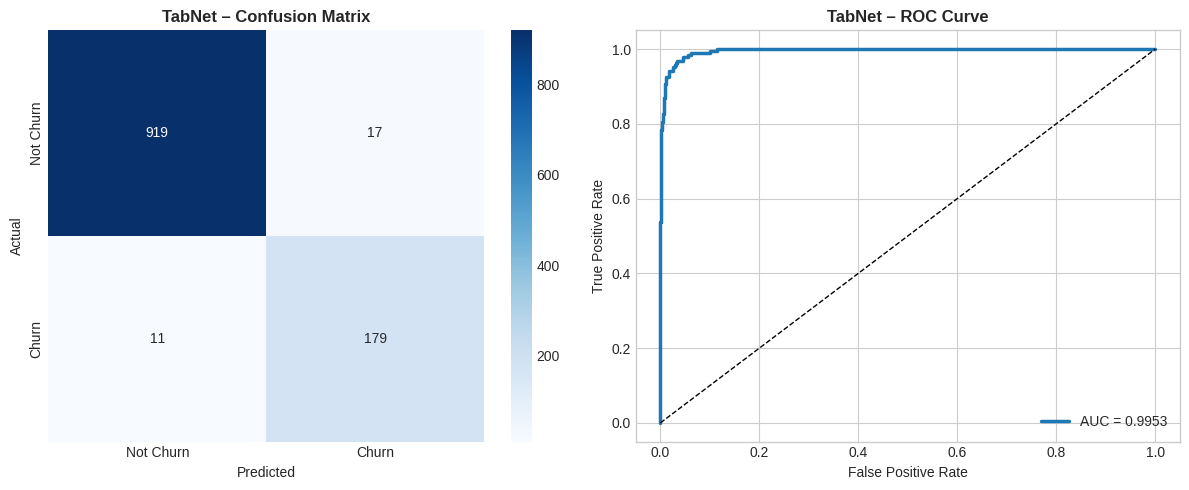

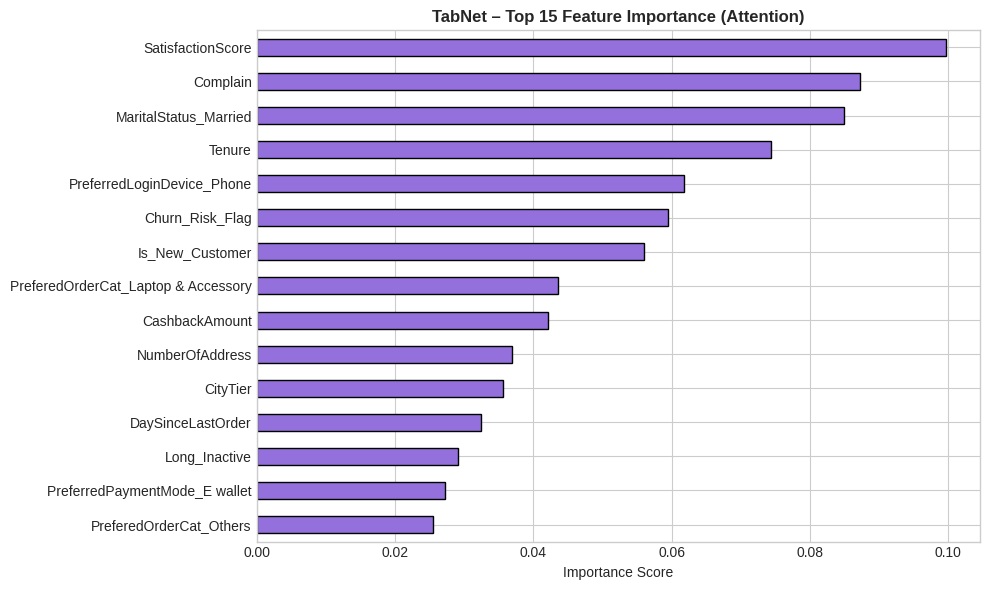

In [30]:
print("🚀 Training TabNet...")
print("Reference: Arik & Pfister, AAAI 2021")
print()

X_train_tn = X_train_sm.values.astype(np.float32)
y_train_tn = y_train_sm.values.astype(int)
X_test_tn = X_test.values.astype(np.float32)
y_test_tn = y_test.values.astype(int)

tabnet_model = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.3,
    n_independent=2, n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='entmax',
    verbose=10, seed=SEED
)

tabnet_model.fit(
    X_train_tn, y_train_tn,
    eval_set=[(X_test_tn, y_test_tn)],
    eval_metric=['auc'],
    max_epochs=100, patience=15,
    batch_size=512, virtual_batch_size=128,
    num_workers=0, drop_last=False
)

y_pred_tn = tabnet_model.predict(X_test_tn)
y_prob_tn = tabnet_model.predict_proba(X_test_tn)[:, 1]

result_tn = evaluate_model('TabNet', y_test_tn, y_pred_tn, y_prob_tn)
results_list.append(result_tn)
plot_confusion_roc('TabNet', y_test_tn, y_pred_tn, y_prob_tn)

# Attention weights = feature importance
feat_imp_tn = pd.Series(
    tabnet_model.feature_importances_, index=X_test.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp_tn.sort_values().plot(kind='barh', color='mediumpurple',
                                  edgecolor='black')
plt.title('TabNet – Top 15 Feature Importance (Attention)',
           fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 📊 14. Model Comparison – Summary

In [31]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 85)
print("MODEL COMPARISON – STAT3013 CHURN PREDICTION")
print("=" * 85)
display_cols = ['Model', 'Accuracy', 'F1_weighted', 'F1_Churn',
                'Precision', 'Recall', 'ROC_AUC', 'PR_AUC']
print(results_df[display_cols].to_string(index=True))

print(f"\n🏆 Best model (ROC-AUC): {results_df.iloc[0]['Model']}")
print(f"   ROC-AUC: {results_df.iloc[0]['ROC_AUC']:.4f}")
print(f"   F1-Churn: {results_df.iloc[0]['F1_Churn']:.4f}")

MODEL COMPARISON – STAT3013 CHURN PREDICTION
            Model  Accuracy  F1_weighted  F1_Churn  Precision    Recall   ROC_AUC    PR_AUC
1        LightGBM  0.990231     0.990157  0.970509   0.989071  0.952632  0.997723  0.991117
2        CatBoost  0.976021     0.975788  0.927224   0.950276  0.905263  0.997436  0.987968
3          TabNet  0.975133     0.975287  0.927461   0.913265  0.942105  0.995299  0.978771
4  FT-Transformer  0.964476     0.964401  0.894180   0.898936  0.889474  0.985358  0.959662

🏆 Best model (ROC-AUC): LightGBM
   ROC-AUC: 0.9977
   F1-Churn: 0.9705


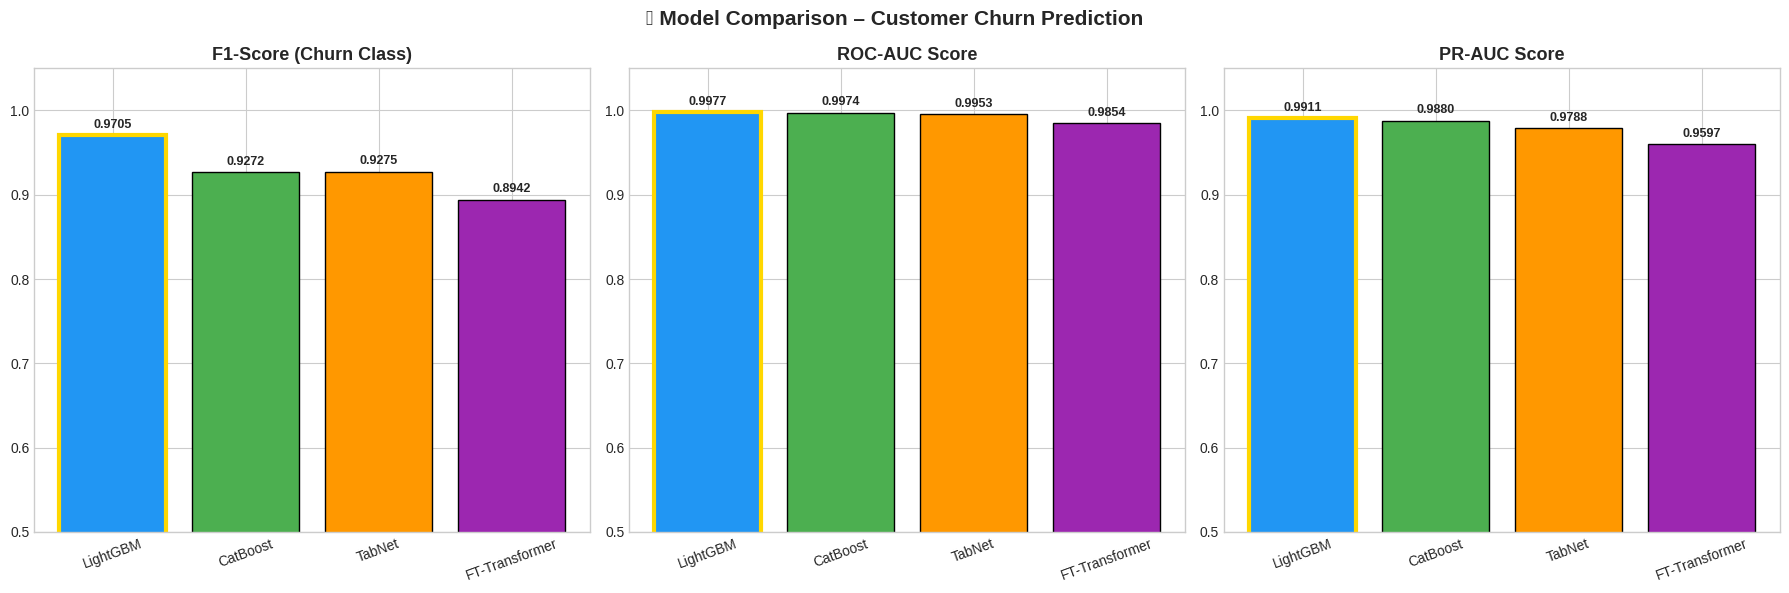

✅ Saved: model_comparison.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['F1_Churn', 'ROC_AUC', 'PR_AUC']
titles = ['F1-Score (Churn Class)', 'ROC-AUC Score', 'PR-AUC Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[i].bar(results_df['Model'], results_df[metric],
                        color=colors[:len(results_df)], edgecolor='black')
    axes[i].set_title(title, fontweight='bold', fontsize=13)
    axes[i].set_ylim(0.5, 1.05)
    axes[i].tick_params(axis='x', rotation=20)

    best_idx = results_df[metric].idxmax() - 1
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                      f'{val:.4f}', ha='center', va='bottom',
                      fontsize=9, fontweight='bold')

plt.suptitle('🏆 Model Comparison – Customer Churn Prediction',
              fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

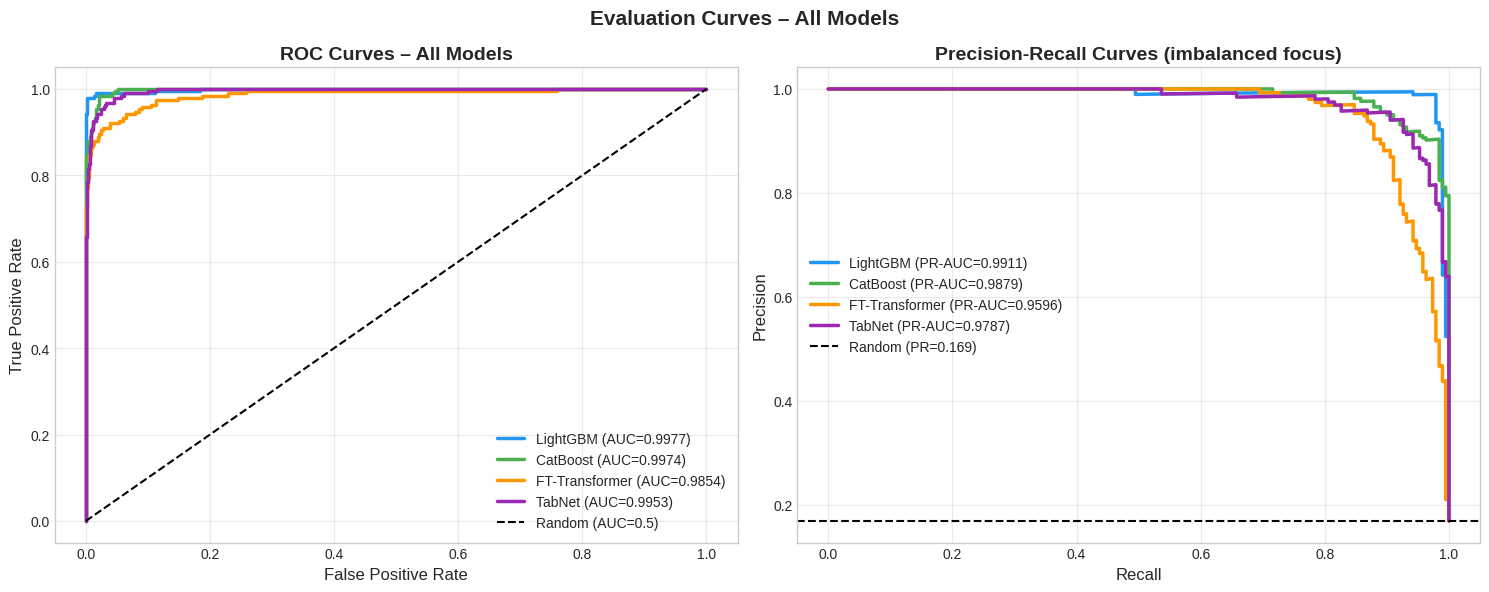

✅ Saved: roc_pr_curves.png


In [33]:
# ROC & PR Curves for all models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

model_probs = [
    ('LightGBM',       y_prob_lgb, '#2196F3'),
    ('CatBoost',       y_prob_cat, '#4CAF50'),
    ('FT-Transformer', y_prob_ft,  '#FF9800'),
    ('TabNet',         y_prob_tn,  '#9C27B0'),
]

y_test_arr = np.array(y_test)

for name, probs, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test_arr, probs)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2.5,
                  label=f'{name} (AUC={roc_auc_val:.4f})', color=color)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves – All Models', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

for name, probs, color in model_probs:
    prec_c, rec_c, _ = precision_recall_curve(y_test_arr, probs)
    pr_auc_val = auc(rec_c, prec_c)
    axes[1].plot(rec_c, prec_c, lw=2.5,
                  label=f'{name} (PR-AUC={pr_auc_val:.4f})', color=color)

baseline_pr = y_test_arr.mean()
axes[1].axhline(baseline_pr, ls='--', color='k', lw=1.5,
                 label=f'Random (PR={baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves (imbalanced focus)',
                   fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Evaluation Curves – All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_pr_curves.png")

## 📤 15. Export CSV for Looker Studio Dashboard

**Workflow:**
1. Export the CSV below
2. Upload to Google Sheets
3. Open Looker Studio → create a data source from Google Sheets
4. Build 3 pages: **Executive Summary | Diagnostic | Actionable List**

(See the companion file `HUONG_DAN_LOOKER_STUDIO.md` for details.)

In [34]:
# ---- Choose the best model for export ----
# Default: LightGBM (stable + SHAP available). Swap y_prob_XXX for another model.
best_model_name = 'LightGBM'
best_probs = y_prob_lgb
best_preds = y_pred_lgb

# To switch model:
# best_model_name = 'CatBoost'
# best_probs = y_prob_cat
# best_preds = y_pred_cat

test_indices = y_test.index
df_export = df.loc[test_indices].copy()

df_export['Churn_Probability'] = np.round(best_probs, 4)
df_export['Predicted_Churn'] = best_preds

df_export['Risk_Level'] = pd.cut(
    best_probs,
    bins=[0, 0.3, 0.6, 0.8, 1.01],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# SHAP top reason (from LightGBM)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap_df = pd.DataFrame(sv, columns=X_test.columns, index=test_indices)
df_export['Top_Churn_Reason'] = shap_df.abs().idxmax(axis=1).values

# Recommended action (business logic)
def suggest_action(row):
    if row['Complain'] == 1 and row['Churn_Probability'] > 0.6:
        return 'Urgent: Send 50k voucher within 1 hour'
    elif row['Tenure'] < 3 and row['Churn_Probability'] > 0.4:
        return 'Onboarding: Free shipping for next 3 orders'
    elif row['SatisfactionScore'] <= 2:
        return 'Survey + personal follow-up call'
    elif row['Churn_Probability'] > 0.8:
        return 'VIP retention: call & offer exclusive deal'
    else:
        return 'Monitor: include in loyalty program'

df_export['Recommended_Action'] = df_export.apply(suggest_action, axis=1)
df_export['Model_Used'] = best_model_name

export_cols = [
    'CustomerID', 'Churn', 'Predicted_Churn', 'Churn_Probability',
    'Risk_Level', 'Top_Churn_Reason', 'Recommended_Action', 'Model_Used',
    'Tenure', 'SatisfactionScore', 'Complain',
    'WarehouseToHome', 'CityTier', 'PreferedOrderCat',
    'CashbackAmount', 'OrderCount', 'DaySinceLastOrder',
    'Gender', 'MaritalStatus', 'PreferredPaymentMode'
]
export_cols = [c for c in export_cols if c in df_export.columns]

df_export[export_cols].to_csv('churn_predictions_dashboard.csv', index=False,
                               encoding='utf-8-sig')

print("✅ Saved: churn_predictions_dashboard.csv")
print(f"   • Records:            {len(df_export):,}")
print(f"   • High+Very High Risk: "
      f"{(df_export['Risk_Level'].isin(['High', 'Very High'])).sum()}")
print(f"\n📋 Preview (10 rows):")
df_export[export_cols].head(10)

✅ Saved: churn_predictions_dashboard.csv
   • Records:            1,126
   • High+Very High Risk: 179

📋 Preview (10 rows):


,CustomerID,Churn,Predicted_Churn,Churn_Probability,Risk_Level,Top_Churn_Reason,Recommended_Action,Model_Used,Tenure,SatisfactionScore,Complain,WarehouseToHome,CityTier,PreferedOrderCat,CashbackAmount,OrderCount,DaySinceLastOrder,Gender,MaritalStatus,PreferredPaymentMode
4006,54007,0,0,0.0015,Low,Complain,Survey + personal follow-up call,LightGBM,17.0,1,0,9.0,3,Laptop & Accessory,181.75,8.0,8.0,Male,Married,Debit Card
1969,51970,0,0,0.0001,Low,Tenure,Survey + personal follow-up call,LightGBM,26.0,1,1,13.0,3,Fashion,209.34,1.0,NaN,Female,Married,E wallet
4235,54236,0,0,0.0001,Low,Complain,Survey + personal follow-up call,LightGBM,5.0,1,0,15.0,1,Laptop & Accessory,169.24,2.0,9.0,Female,Single,Debit Card
105,50106,0,0,0.0002,Low,Tenure,Survey + personal follow-up call,LightGBM,25.0,2,0,8.0,1,Mobile,132.12,2.0,2.0,Female,Single,Debit Card
2295,52296,0,0,0.0181,Low,MaritalStatus_Single,Monitor: include in loyalty program,LightGBM,4.0,3,1,8.0,3,Fashion,198.52,9.0,6.0,Female,Married,Debit Card
4393,54394,0,0,0.0001,Low,Tenure,Survey + personal follow-up call,LightGBM,24.0,1,0,7.0,3,Others,320.17,2.0,7.0,Female,Married,Credit Card
2951,52952,0,0,0.0114,Low,Complain,Survey + personal follow-up call,LightGBM,12.0,2,0,9.0,3,Laptop & Accessory,177.49,8.0,6.0,Male,Divorced,Debit Card
3403,53404,0,0,0.0001,Low,Complain,Survey + personal follow-up call,LightGBM,19.0,2,0,7.0,1,Mobile Phone,147.70,2.0,3.0,Female,Married,Credit Card
3585,53586,0,0,0.0020,Low,Is_New_Customer,Monitor: include in loyalty program,LightGBM,5.0,5,1,18.0,1,Laptop & Accessory,193.33,2.0,2.0,Male,Divorced,Credit Card
467,50468,0,0,0.0005,Low,Tenure,Survey + personal follow-up call,LightGBM,20.0,2,1,8.0,1,Grocery,267.52,3.0,0.0,Female,Divorced,UPI


In [35]:
# ---- Dashboard summary statistics ----
print("=" * 60)
print("DASHBOARD SUMMARY STATISTICS")
print("=" * 60)

total_customers = len(df_export)
high_risk = (df_export['Risk_Level'].isin(['High', 'Very High'])).sum()
avg_cashback_at_risk = df_export[
    df_export['Risk_Level'].isin(['High', 'Very High'])
]['CashbackAmount'].mean()
est_revenue_loss = high_risk * avg_cashback_at_risk * 12

print(f"Total customers (test set):      {total_customers:,}")
print(f"High + Very High Risk:           {high_risk:,} "
      f"({high_risk/total_customers*100:.1f}%)")
print(f"Avg cashback for at-risk group:  {avg_cashback_at_risk:,.2f}")
print(f"Estimated annual revenue at risk: {est_revenue_loss:,.0f}")

print("\nPredicted churn rate by CityTier:")
by_city = df_export.groupby('CityTier').agg(
    Total=('CustomerID', 'count'),
    Predicted_Churn_Rate=('Predicted_Churn', 'mean')
)
by_city['Predicted_Churn_Rate'] = (by_city['Predicted_Churn_Rate'] * 100).round(2)
print(by_city)

print("\n🎯 Next steps:")
print("   1. Download churn_predictions_dashboard.csv")
print("   2. Upload to Google Sheets (drive.google.com)")
print("   3. Open Looker Studio (lookerstudio.google.com)")
print("   4. Connect data source → Google Sheets")
print("   5. Build 3 pages: Executive / Diagnostic / Actionable")
print("\n📖 See HUONG_DAN_LOOKER_STUDIO.md for detailed instructions")

DASHBOARD SUMMARY STATISTICS
Total customers (test set):      1,126
High + Very High Risk:           179 (15.9%)
Avg cashback for at-risk group:  161.12
Estimated annual revenue at risk: 346,087

Predicted churn rate by CityTier:
          Total  Predicted_Churn_Rate
CityTier                             
1           759                 15.02
2            43                 18.60
3           324                 18.83

🎯 Next steps:
   1. Download churn_predictions_dashboard.csv
   2. Upload to Google Sheets (drive.google.com)
   3. Open Looker Studio (lookerstudio.google.com)
   4. Connect data source → Google Sheets
   5. Build 3 pages: Executive / Diagnostic / Actionable

📖 See HUONG_DAN_LOOKER_STUDIO.md for detailed instructions


## 🏁 16. Conclusions & Business Implications

In [36]:
print("=" * 75)
print("  CONCLUSIONS & BUSINESS IMPLICATIONS – CUSTOMER CHURN PREDICTION")
print("=" * 75)

print("""
📊 DATASET & METHODOLOGY SUMMARY:
────────────────────────────────────────────────────────────
 • Dataset:     5,630 customers | 20 features | 16.84% churn rate
 • Imbalance:   SMOTE oversampling (training set only)
 • Preprocess:  KNN Imputer + Winsorization + OHE(drop_first=True)
 • Feature Eng: 7 business-meaningful engineered features
 • Metrics:     F1-Score, ROC-AUC, PR-AUC (NOT only accuracy)
 • Validation:  5-Fold Stratified Cross-Validation

🤖 MODELS (2024-2025 SOTA):
────────────────────────────────────────────────────────────
 ML1: LightGBM           – Fast GBDT, SHAP support
 ML2: CatBoost           – Native categorical, NeurIPS 2018
 DL1: FT-Transformer     – Transformer for tabular, NeurIPS 2021
 DL2: TabNet             – Attentive DL, AAAI 2021
""")

print("🏆 RESULTS SUMMARY:")
for idx, row in results_df.iterrows():
    medal = "🥇" if idx == 1 else ("🥈" if idx == 2 else
             ("🥉" if idx == 3 else "  "))
    print(f"  {medal} {row['Model']:20s}: "
           f"AUC={row['ROC_AUC']:.4f} | F1={row['F1_Churn']:.4f} | "
           f"PR-AUC={row['PR_AUC']:.4f}")

print("""

💡 TOP CHURN DRIVERS (from SHAP – LightGBM):
────────────────────────────────────────────────────────────
 1. Complain = 1           → Complained customers, high risk
 2. Low Tenure             → New customers (0-3 months) churn most
 3. WarehouseToHome far    → Slow delivery → frustration
 4. Low SatisfactionScore  → Poor experience
 5. Low CashbackAmount     → Feeling undervalued

🎯 BUSINESS RECOMMENDATIONS (actionable):
────────────────────────────────────────────────────────────
 ✅ Support:      Complain=1 → auto 50k voucher within 1 hour
 ✅ Onboarding:   30-day program with free ship + tiered cashback
 ✅ Logistics:    Open micro-warehouses in City Tier 2-3, optimize SLA
 ✅ VIP:          Call customers flagged 'Very High' risk
 ✅ Smart Voucher: Only for 'High Risk but Persuadable' segment
 ✅ CLV Priority: Retention budget → high CLV + high churn risk
""")

print("=" * 75)
print("✅ Complete pipeline | STAT3013 – Customer Churn Prediction")
print("=" * 75)

  CONCLUSIONS & BUSINESS IMPLICATIONS – CUSTOMER CHURN PREDICTION

📊 DATASET & METHODOLOGY SUMMARY:
────────────────────────────────────────────────────────────
 • Dataset:     5,630 customers | 20 features | 16.84% churn rate
 • Imbalance:   SMOTE oversampling (training set only)
 • Preprocess:  KNN Imputer + Winsorization + OHE(drop_first=True)
 • Feature Eng: 7 business-meaningful engineered features
 • Metrics:     F1-Score, ROC-AUC, PR-AUC (NOT only accuracy)
 • Validation:  5-Fold Stratified Cross-Validation

🤖 MODELS (2024-2025 SOTA):
────────────────────────────────────────────────────────────
 ML1: LightGBM           – Fast GBDT, SHAP support
 ML2: CatBoost           – Native categorical, NeurIPS 2018
 DL1: FT-Transformer     – Transformer for tabular, NeurIPS 2021
 DL2: TabNet             – Attentive DL, AAAI 2021

🏆 RESULTS SUMMARY:
  🥇 LightGBM            : AUC=0.9977 | F1=0.9705 | PR-AUC=0.9911
  🥈 CatBoost            : AUC=0.9974 | F1=0.9272 | PR-AUC=0.9880
  🥉 TabNet    